# Đồ án Học máy — SV16
## So sánh dự báo Flow giữa hai tập Sensor trong PeMSD3

**Nhóm 2** — Dữ liệu PeMSD (flow, speed, occupancy)

---

## 1. Cài đặt và nhập thư viện

### 1.1. Cài đặt thư viện

In [1]:
import subprocess
import sys

def install_package(package):
    subprocess.check_call([sys.executable, "-m", "pip", "install", package])

# Đọc danh sách packages từ requirements.txt
with open('requirements.txt', 'r') as f:
    required_packages = [line.strip() for line in f if line.strip() and not line.startswith('#')]

print("Đang kiểm tra và cài đặt các thư viện cần thiết...")
for package in required_packages:
    try:
        install_package(package)
        print(f"✅ {package} đã được cài đặt")
    except Exception as e:
        print(f"❌ Lỗi khi cài đặt {package}: {e}")

print(f"\nHoàn tất! Đã xử lý {len(required_packages)} packages.")

Đang kiểm tra và cài đặt các thư viện cần thiết...
✅ pandas>=2.0 đã được cài đặt
✅ numpy>=1.24 đã được cài đặt
✅ scikit-learn>=1.3 đã được cài đặt
✅ xgboost>=2.0 đã được cài đặt
✅ torch>=2.0 đã được cài đặt
✅ matplotlib>=3.7 đã được cài đặt
✅ seaborn>=0.12 đã được cài đặt
✅ plotly>=5.15 đã được cài đặt
✅ ipywidgets>=8.0 đã được cài đặt
✅ joblib đã được cài đặt
✅ pymoo>=0.6.0 đã được cài đặt
✅ shap>=0.45 đã được cài đặt

Hoàn tất! Đã xử lý 12 packages.


### 1.2. Nhập thư viện

In [2]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import modules của dự án
from modules import data_loader
from modules import eda
from modules import feature_engineering as fe
from modules import models
from modules import visualization as viz
from modules import comparison
from modules import stability
from modules import error_analysis
from modules import explainability
from modules import gan_synthetic

# Auto-reload modules khi chỉnh sửa code
%load_ext autoreload
%autoreload 2
%matplotlib inline

print('✅ Đã nhập tất cả thư viện thành công!')


✅ Đã nhập tất cả thư viện thành công!


---
## 2. Kiểm tra GPU

In [3]:
import torch

print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU device     : {torch.cuda.get_device_name(0)}')
    print(f'GPU memory     : {torch.cuda.get_device_properties(0).total_mem / 1e9:.1f} GB')
else:
    print('⚠️ Không có GPU — LSTM sẽ chạy trên CPU (chậm hơn)')

PyTorch version: 2.12.0+cpu
CUDA available : False
⚠️ Không có GPU — LSTM sẽ chạy trên CPU (chậm hơn)


---
## 3. Cấu hình (CONFIG)

**Tất cả thông số** có thể chỉnh sửa đều nằm ở đây.

In [4]:
from configs.configs import CONFIG

print('✅ CONFIG đã thiết lập')
print(f'   Baseline A sensors: {CONFIG["baseline_a_sensors"]}')
print(f'   Baseline B sensors: {CONFIG["baseline_b_sensors"]}')
print(f'   Split: Train {CONFIG["train_ratio"]*100:.0f}% / '
      f'Valid {CONFIG["valid_ratio"]*100:.0f}% / '
      f'Test {(1-CONFIG["train_ratio"]-CONFIG["valid_ratio"])*100:.0f}%')

✅ CONFIG đã thiết lập
   Baseline A sensors: ['PEMSD3_007', 'PEMSD3_008', 'PEMSD3_009', 'PEMSD3_010']
   Baseline B sensors: ['PEMSD3_011', 'PEMSD3_012', 'PEMSD3_013', 'PEMSD3_014']
   Split: Train 70% / Valid 15% / Test 15%


---
## 4. Xử lý dữ liệu

### 4.1. Nhập dữ liệu

In [5]:
# Load dữ liệu gốc
df_raw = data_loader.load_raw_data(CONFIG['data_path'])

# Thông tin tổng quan
info = data_loader.get_data_info(df_raw)
data_loader.print_data_info(info)

✅ Đã load 48,384 dòng từ SV16_PeMSD3_sample_8sensors.csv
   Sensors: ['PEMSD3_007', 'PEMSD3_008', 'PEMSD3_009', 'PEMSD3_010', 'PEMSD3_011', 'PEMSD3_012', 'PEMSD3_013', 'PEMSD3_014']
   Thời gian: 2024-02-01 00:00:00 → 2024-02-21 23:55:00
📊 THÔNG TIN DATASET
  Tổng số dòng   : 48,384
  Số cột          : 6
  Số sensor       : 8
  Khoảng thời gian: 2024-02-01 00:00:00 → 2024-02-21 23:55:00
  Missing values  : 0

  Số dòng mỗi sensor:
    PEMSD3_007: 6,048 dòng
    PEMSD3_008: 6,048 dòng
    PEMSD3_009: 6,048 dòng
    PEMSD3_010: 6,048 dòng
    PEMSD3_011: 6,048 dòng
    PEMSD3_012: 6,048 dòng
    PEMSD3_013: 6,048 dòng
    PEMSD3_014: 6,048 dòng


In [6]:
# Xem 5 dòng đầu
df_raw.head()

,timestamp,sensor_id,flow,speed,occupancy,district
0,2024-02-01 00:00:00,PEMSD3_007,40.69,53.61,0.3019,D3
1,2024-02-01 00:05:00,PEMSD3_007,35.34,61.20,0.2259,D3
2,2024-02-01 00:10:00,PEMSD3_007,48.23,54.87,0.2803,D3
3,2024-02-01 00:15:00,PEMSD3_007,40.01,60.65,0.2086,D3
4,2024-02-01 00:20:00,PEMSD3_007,47.15,52.11,0.3292,D3


In [7]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 48384 entries, 0 to 48383
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  48384 non-null  datetime64[us]
 1   sensor_id  48384 non-null  str           
 2   flow       48384 non-null  float64       
 3   speed      48384 non-null  float64       
 4   occupancy  48384 non-null  float64       
 5   district   48384 non-null  str           
dtypes: datetime64[us](1), float64(3), str(2)
memory usage: 2.2 MB


### 4.2. Thống kê mô tả & EDA

In [8]:
# Thống kê mô tả per sensor
stats = eda.describe_per_sensor(df_raw)
stats.T

sensor_id        PEMSD3_007  PEMSD3_008  PEMSD3_009  PEMSD3_010  PEMSD3_011  \
flow      count     6048.00     6048.00     6048.00     6048.00     6048.00   
          mean        73.67       78.80       84.62       90.51       67.70   
          std         33.60       35.88       38.37       40.73       31.36   
          min          5.00        5.00        5.00       12.60        5.00   
          25%         47.04       50.17       54.27       58.01       43.02   
          50%         65.44       69.22       73.24       78.13       59.78   
          75%         99.02      105.42      114.11      122.19       90.94   
          max        174.09      188.52      218.03      207.37      172.89   
speed     count     6048.00     6048.00     6048.00     6048.00     6048.00   
          mean        51.80       50.90       49.80       48.66       52.86   
          std          6.74        7.01        7.50        7.93        6.39   
          min         29.20       26.01       24.20       22.82       30.01   
          25%         47.08       46.01       44.41       42.95       48.49   
          50%         52.73       52.06       51.12       50.16       53.62   
          75%         56.88       56.21       55.49       54.80       57.60   
          max         69.39       68.14       68.38       69.24       71.60   
occupancy count     6048.00     6048.00     6048.00     6048.00     6048.00   
          mean         0.44        0.47        0.50        0.53        0.40   
          std          0.20        0.21        0.22        0.23        0.19   
          min          0.02        0.02        0.04        0.04        0.02   
          25%          0.28        0.30        0.32        0.34        0.25   
          50%          0.39        0.41        0.44        0.47        0.36   
          75%          0.59        0.63        0.68        0.73        0.54   
          max          0.92        0.92        0.92        0.92        0.92   

sensor_id        PEMSD3_012  PEMSD3_013  PEMSD3_014  
flow      count     6048.00     6048.00     6048.00  
          mean        73.24       78.93       84.90  
          std         33.60       36.12       38.05  
          min          5.00        5.00       11.59  
          25%         46.61       50.17       54.75  
          50%         64.28       69.01       73.96  
          75%         98.63      106.52      113.83  
          max        170.33      189.50      193.02  
speed     count     6048.00     6048.00     6048.00  
          mean        51.83       50.81       49.80  
          std          6.76        7.14        7.48  
          min         31.24       26.90       27.38  
          25%         47.02       45.72       44.43  
          50%         52.80       51.96       51.11  
          75%         56.88       56.22       55.53  
          max         68.65       70.49       68.01  
occupancy count     6048.00     6048.00     6048.00  
          mean         0.43        0.47        0.50  
          std          0.20        0.21        0.22  
          min          0.03        0.02        0.06  
          25%          0.28        0.30        0.32  
          50%          0.38        0.41        0.44  
          75%          0.59        0.63        0.67  
          max          0.92        0.92        0.92

In [9]:
# Kiểm tra missing data
missing_report = eda.check_missing(df_raw)
missing_report

,sensor_id,n_rows,n_null_values,missing_rate_%,n_time_gaps
0,PEMSD3_007,6048,0,0.0,0
1,PEMSD3_008,6048,0,0.0,0
2,PEMSD3_009,6048,0,0.0,0
3,PEMSD3_010,6048,0,0.0,0
4,PEMSD3_011,6048,0,0.0,0
5,PEMSD3_012,6048,0,0.0,0
6,PEMSD3_013,6048,0,0.0,0
7,PEMSD3_014,6048,0,0.0,0


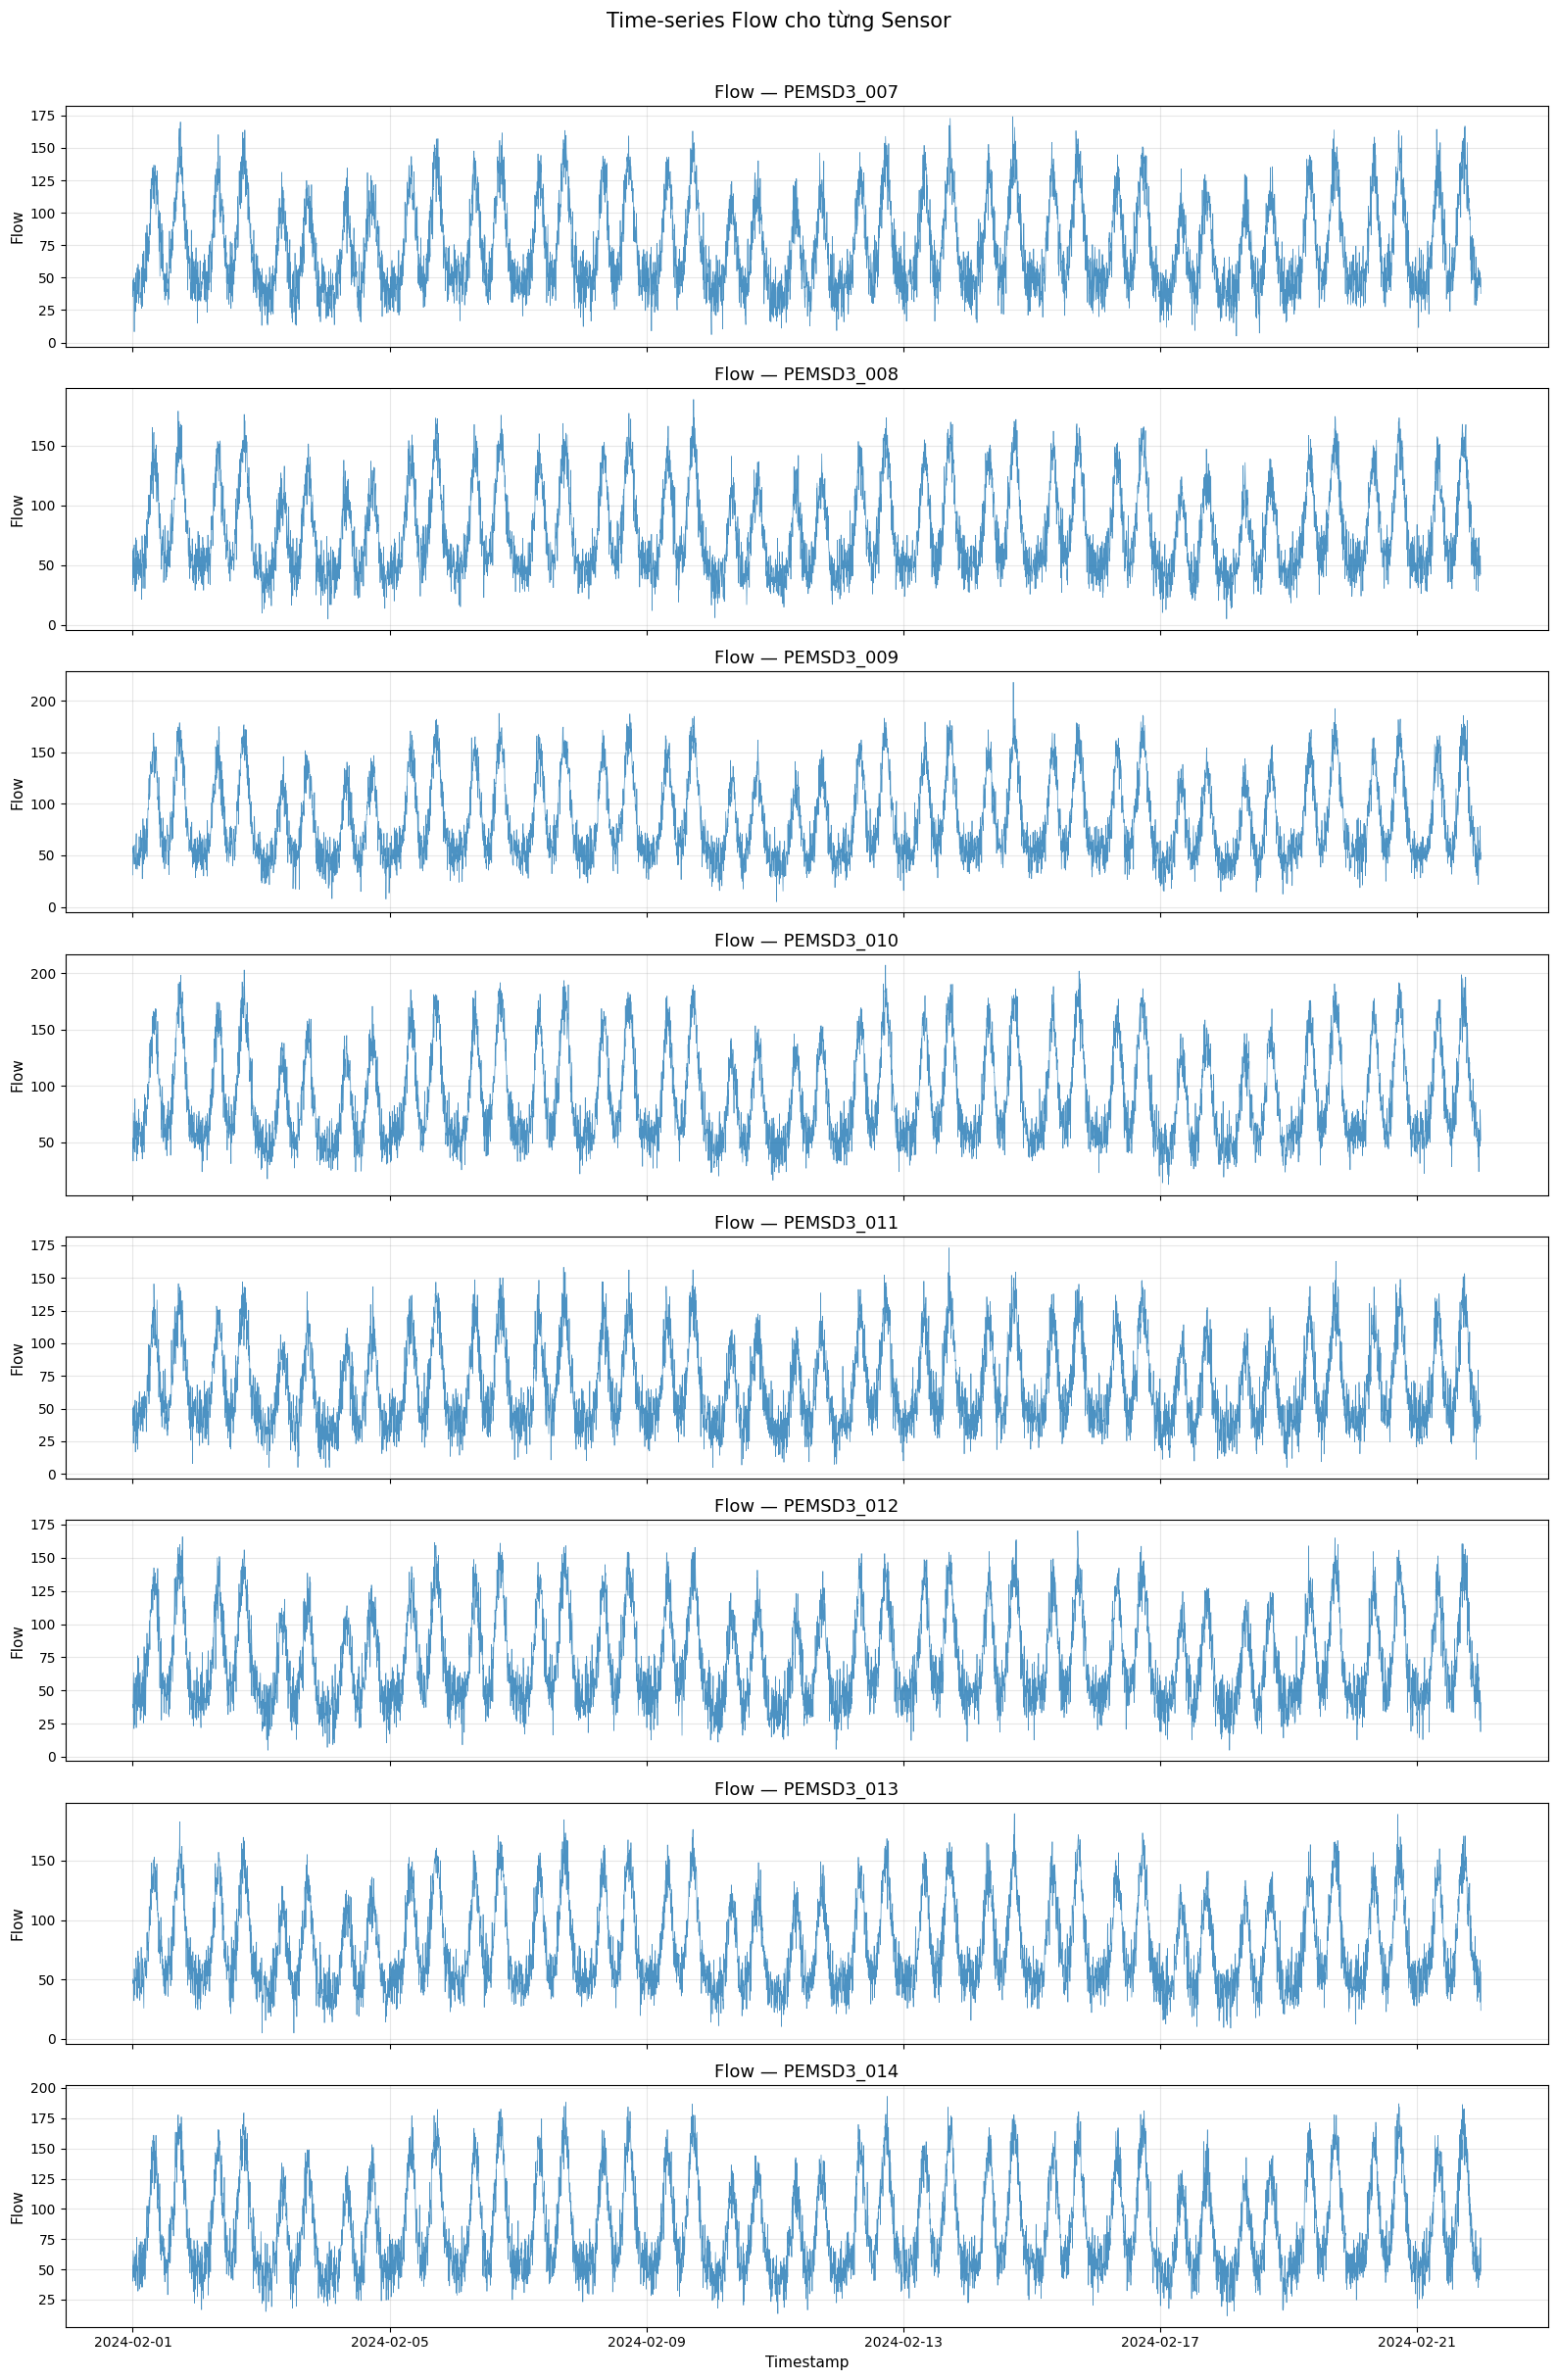

In [10]:
# Biểu đồ time-series flow cho từng sensor
eda.plot_timeseries_flow(df_raw, save_dir=CONFIG['images_dir'])

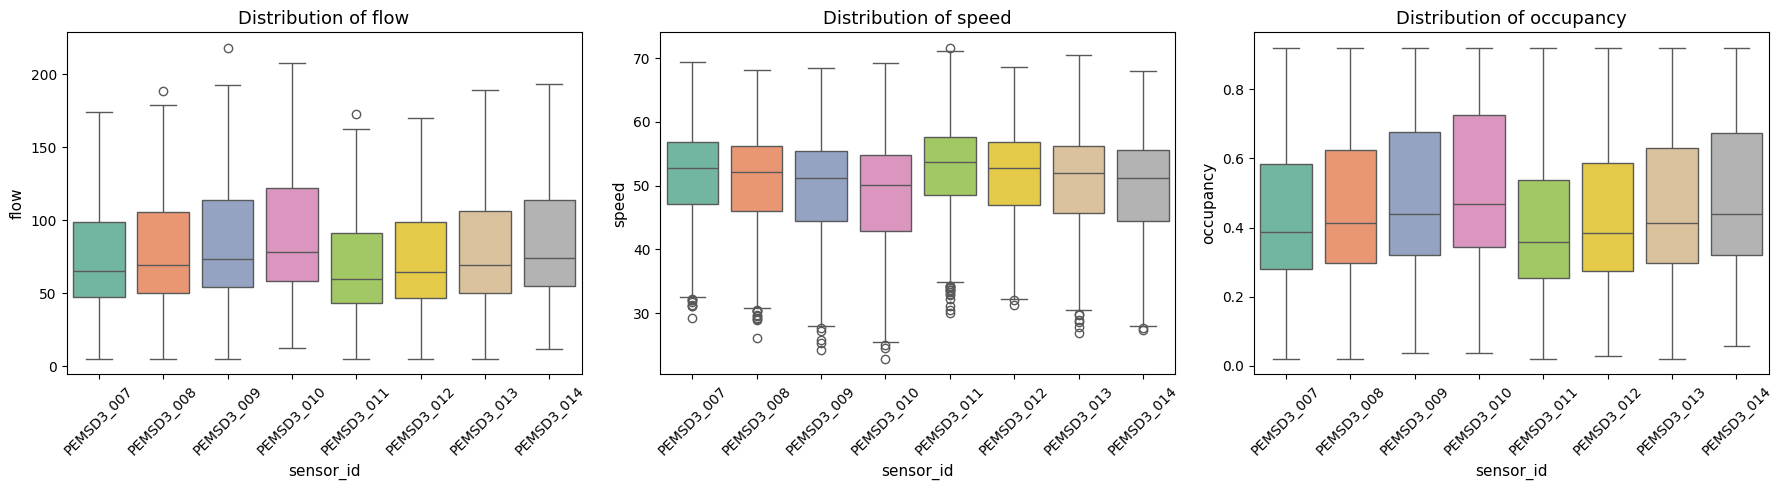

In [11]:
# Distribution boxplot
eda.plot_distribution(df_raw, save_dir=CONFIG['images_dir'])

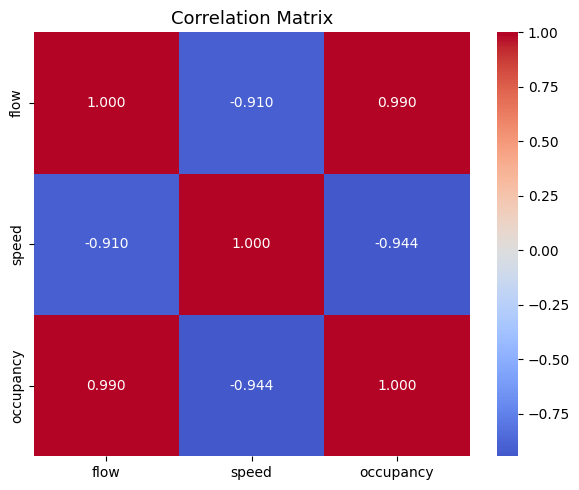

In [12]:
# Correlation heatmap
eda.plot_correlation(df_raw, save_dir=CONFIG['images_dir'])

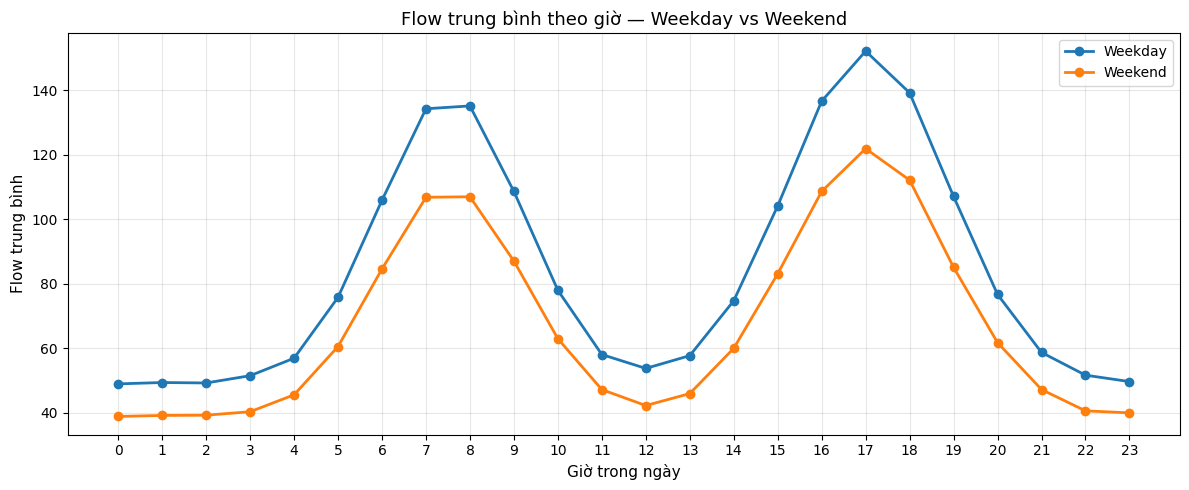

In [13]:
# Hourly pattern: Weekday vs Weekend
eda.plot_hourly_pattern(df_raw, save_dir=CONFIG['images_dir'])

### 4.3. Feature Engineering

In [14]:
# Tạo toàn bộ features: time + lag + rolling + target
df_featured = fe.prepare_all_features(df_raw, CONFIG)

# Kiểm tra kết quả
print(f'\nShape sau feature engineering: {df_featured.shape}')
print(f'Columns: {list(df_featured.columns)}')
df_featured.head()

✅ Đã thêm time features: hour, weekday, is_weekend, time_slot
✅ Đã thêm 15 lag features (lags=[1, 2, 3, 6, 12], cols=['flow', 'speed', 'occupancy'])
✅ Đã thêm 18 rolling features (windows=[3, 6, 12])
✅ Đã tạo target: flow_target (t+3 = 15 phút)
✅ Drop NaN: 48,384 → 48,264 dòng (mất 120)

Shape sau feature engineering: (48264, 44)
Columns: ['timestamp', 'sensor_id', 'flow', 'speed', 'occupancy', 'district', 'hour', 'weekday', 'is_weekend', 'time_slot', 'flow_lag_1', 'flow_lag_2', 'flow_lag_3', 'flow_lag_6', 'flow_lag_12', 'speed_lag_1', 'speed_lag_2', 'speed_lag_3', 'speed_lag_6', 'speed_lag_12', 'occupancy_lag_1', 'occupancy_lag_2', 'occupancy_lag_3', 'occupancy_lag_6', 'occupancy_lag_12', 'flow_roll_mean_3', 'flow_roll_std_3', 'flow_roll_mean_6', 'flow_roll_std_6', 'flow_roll_mean_12', 'flow_roll_std_12', 'speed_roll_mean_3', 'speed_roll_std_3', 'speed_roll_mean_6', 'speed_roll_std_6', 'speed_roll_mean_12', 'speed_roll_std_12', 'occupancy_roll_mean_3', 'occupancy_roll_std_3', 'occupan

,timestamp,sensor_id,flow,speed,occupancy,district,hour,weekday,is_weekend,time_slot,...,speed_roll_std_6,speed_roll_mean_12,speed_roll_std_12,occupancy_roll_mean_3,occupancy_roll_std_3,occupancy_roll_mean_6,occupancy_roll_std_6,occupancy_roll_mean_12,occupancy_roll_std_12,flow_target
0,2024-02-01 01:00:00,PEMSD3_007,23.97,65.17,0.1349,D3,1,3,0,0,...,3.554916,58.032500,4.257511,0.203433,0.063798,0.205117,0.083202,0.241242,0.079233,31.66
1,2024-02-01 01:05:00,PEMSD3_007,53.57,54.47,0.3182,D3,1,3,0,0,...,3.881698,57.471667,4.245579,0.222467,0.091922,0.244450,0.067838,0.248933,0.082038,37.94
2,2024-02-01 01:10:00,PEMSD3_007,35.17,57.18,0.2031,D3,1,3,0,0,...,3.538226,57.664167,4.168563,0.218733,0.092645,0.226817,0.061156,0.242500,0.082381,39.75
3,2024-02-01 01:15:00,PEMSD3_007,31.66,59.90,0.1457,D3,1,3,0,0,...,3.561887,57.601667,4.125122,0.222333,0.087844,0.212883,0.069439,0.237258,0.086626,30.82
4,2024-02-01 01:20:00,PEMSD3_007,37.94,55.18,0.2483,D3,1,3,0,0,...,3.887002,57.857500,3.838840,0.199033,0.051421,0.210750,0.067840,0.230517,0.081836,49.88


In [15]:
# Danh sách feature columns sẽ dùng cho modeling
FEATURE_COLS = fe.get_feature_columns(CONFIG)
TARGET_COL = 'flow_target'

print(f'Số features: {len(FEATURE_COLS)}')
print(f'Features: {FEATURE_COLS}')
print(f'Target: {TARGET_COL}')

Số features: 36
Features: ['flow_lag_1', 'flow_lag_2', 'flow_lag_3', 'flow_lag_6', 'flow_lag_12', 'speed_lag_1', 'speed_lag_2', 'speed_lag_3', 'speed_lag_6', 'speed_lag_12', 'occupancy_lag_1', 'occupancy_lag_2', 'occupancy_lag_3', 'occupancy_lag_6', 'occupancy_lag_12', 'flow_roll_mean_3', 'flow_roll_std_3', 'flow_roll_mean_6', 'flow_roll_std_6', 'flow_roll_mean_12', 'flow_roll_std_12', 'speed_roll_mean_3', 'speed_roll_std_3', 'speed_roll_mean_6', 'speed_roll_std_6', 'speed_roll_mean_12', 'speed_roll_std_12', 'occupancy_roll_mean_3', 'occupancy_roll_std_3', 'occupancy_roll_mean_6', 'occupancy_roll_std_6', 'occupancy_roll_mean_12', 'occupancy_roll_std_12', 'hour', 'weekday', 'is_weekend']
Target: flow_target


### 4.4. Chia Baseline A & Baseline B

In [16]:
df_baseline_a, df_baseline_b = data_loader.split_baselines(
    df_featured,
    CONFIG['baseline_a_sensors'],
    CONFIG['baseline_b_sensors'],
)

✅ Chia Baselines:
   Baseline A: ['PEMSD3_007', 'PEMSD3_008', 'PEMSD3_009', 'PEMSD3_010'] → 24,132 dòng
   Baseline B: ['PEMSD3_011', 'PEMSD3_012', 'PEMSD3_013', 'PEMSD3_014'] → 24,132 dòng


### 4.5. Hold-out Split (Train 70% / Valid 15% / Test 15%)

In [17]:
# Baseline A
print('── Baseline A ──')
train_a, valid_a, test_a = fe.holdout_split(
    df_baseline_a, CONFIG['train_ratio'], CONFIG['valid_ratio']
)

# Baseline B
print('\n── Baseline B ──')
train_b, valid_b, test_b = fe.holdout_split(
    df_baseline_b, CONFIG['train_ratio'], CONFIG['valid_ratio']
)

── Baseline A ──
✅ Hold-out Split (theo thời gian, per sensor):
   Train : 16,892 dòng (70%)
   Valid : 3,620 dòng (15%)
   Test  : 3,620 dòng (15%)

── Baseline B ──
✅ Hold-out Split (theo thời gian, per sensor):
   Train : 16,892 dòng (70%)
   Valid : 3,620 dòng (15%)
   Test  : 3,620 dòng (15%)


In [18]:
# Chuẩn bị X, y cho modeling
X_train_a, y_train_a = train_a[FEATURE_COLS].values, train_a[TARGET_COL].values
X_valid_a, y_valid_a = valid_a[FEATURE_COLS].values, valid_a[TARGET_COL].values
X_test_a,  y_test_a  = test_a[FEATURE_COLS].values,  test_a[TARGET_COL].values

X_train_b, y_train_b = train_b[FEATURE_COLS].values, train_b[TARGET_COL].values
X_valid_b, y_valid_b = valid_b[FEATURE_COLS].values, valid_b[TARGET_COL].values
X_test_b,  y_test_b  = test_b[FEATURE_COLS].values,  test_b[TARGET_COL].values

print(f'Baseline A — X_train: {X_train_a.shape}, X_valid: {X_valid_a.shape}, X_test: {X_test_a.shape}')
print(f'Baseline B — X_train: {X_train_b.shape}, X_valid: {X_valid_b.shape}, X_test: {X_test_b.shape}')

Baseline A — X_train: (16892, 36), X_valid: (3620, 36), X_test: (3620, 36)
Baseline B — X_train: (16892, 36), X_valid: (3620, 36), X_test: (3620, 36)


In [19]:
# Lưu datasets đã xử lý (tuỳ chọn)
import os
os.makedirs(CONFIG['clean_dir'], exist_ok=True)

train_a.to_csv(f"{CONFIG['clean_dir']}/baselineA_train.csv", index=False)
valid_a.to_csv(f"{CONFIG['clean_dir']}/baselineA_valid.csv", index=False)
test_a.to_csv(f"{CONFIG['clean_dir']}/baselineA_test.csv", index=False)
train_b.to_csv(f"{CONFIG['clean_dir']}/baselineB_train.csv", index=False)
valid_b.to_csv(f"{CONFIG['clean_dir']}/baselineB_valid.csv", index=False)
test_b.to_csv(f"{CONFIG['clean_dir']}/baselineB_test.csv", index=False)

print(f'✅ Đã lưu datasets vào {CONFIG["clean_dir"]}/')

✅ Đã lưu datasets vào __datasets-clean/


---
## 5. Xây dựng mô hình Baseline

Huấn luyện **10 mô hình** (3 trivial baselines + 7 ML) cho mỗi baseline:
1. Linear Regression
2. Ridge Regression
3. KNN Regressor
4. Decision Tree Regressor
5. Random Forest Regressor
6. XGBoost Regressor
4. Decision Tree Regressor\n",
    "5. Random Forest Regressor\n",
    "6. XGBoost Regressor\n",
    "7. LSTM

### 5.1. Huấn luyện 10 mô hình cho Baseline A

In [20]:
models_a = models.get_models(CONFIG)
results_a, trained_a = models.train_and_evaluate(
    models_a, X_train_a, y_train_a,
    X_valid_a, y_valid_a,
    X_test_a, y_test_a,
    baseline_name='Baseline_A'
)
results_a


🚀 HUẤN LUYỆN Baseline_A — 10 mô hình

--- 0a_SeasonalNaive ---
   Train — MAE=24.05  RMSE=29.67  R²=0.3809  MASE=1.7561
   Valid — MAE=23.14  RMSE=28.32  R²=0.3980  MASE=1.6894
   Test  — MAE=24.89  RMSE=30.42  R²=0.3902  MASE=1.8171
   ⏱ Thời gian huấn luyện: 0.000s

--- 0b_DriftMethod ---
   Train — MAE=14.50  RMSE=18.19  R²=0.7673  MASE=1.0582
   Valid — MAE=14.52  RMSE=18.10  R²=0.7540  MASE=1.0598
   Test  — MAE=14.73  RMSE=18.48  R²=0.7750  MASE=1.0752
   ⏱ Thời gian huấn luyện: 0.000s

--- 0c_SMA ---
   Train — MAE=15.13  RMSE=18.75  R²=0.7527  MASE=1.1049
   Valid — MAE=14.48  RMSE=18.00  R²=0.7568  MASE=1.0573
   Test  — MAE=15.51  RMSE=19.07  R²=0.7603  MASE=1.1325
   ⏱ Thời gian huấn luyện: 0.000s

--- 1_LinearRegression ---
   Train — MAE=11.41  RMSE=14.28  R²=0.8566  MASE=0.8332
   Valid — MAE=11.41  RMSE=14.23  R²=0.8480  MASE=0.8329
   Test  — MAE=11.41  RMSE=14.28  R²=0.8657  MASE=0.8331
   ⏱ Thời gian huấn luyện: 0.278s

--- 2_Ridge ---
   Train — MAE=11.42  RMSE=14.2

,model,baseline,train_time_s,train_MAE,train_RMSE,train_MAPE,train_R2,train_MASE,valid_MAE,valid_RMSE,valid_MAPE,valid_R2,valid_MASE,test_MAE,test_RMSE,test_MAPE,test_R2,test_MASE
0,5_RandomForest,Baseline_A,3.488,5.5352,6.8738,9.2741,0.9668,0.4041,10.5536,13.2111,18.6125,0.8690,0.7704,10.3849,13.0622,15.5648,0.8876,0.7581
1,6_XGBoost,Baseline_A,2.437,4.3002,5.6472,6.7944,0.9776,0.3139,10.4520,13.1215,18.4215,0.8707,0.7630,10.5081,13.2118,15.7194,0.8850,0.7671
2,7_LSTM,Baseline_A,36.068,10.4762,13.1561,16.9151,0.8783,0.7648,10.7286,13.4861,18.9445,0.8635,0.7832,10.6163,13.3423,15.8998,0.8827,0.7750
3,3_KNN,Baseline_A,0.001,0.0000,0.0000,0.0000,1.0000,0.0000,11.4049,14.3594,20.3122,0.8452,0.8326,11.1509,14.0142,16.5389,0.8706,0.8141
4,1_LinearRegression,Baseline_A,0.278,11.4132,14.2807,18.4205,0.8566,0.8332,11.4087,14.2274,20.1422,0.8480,0.8329,11.4111,14.2762,17.2474,0.8657,0.8331
5,2_Ridge,Baseline_A,0.021,11.4152,14.2823,18.4222,0.8566,0.8334,11.4042,14.2251,20.1421,0.8481,0.8325,11.4141,14.2800,17.2441,0.8656,0.8333
6,4_DecisionTree,Baseline_A,0.540,3.8568,6.3965,6.5708,0.9712,0.2816,14.0786,17.8096,23.7846,0.7619,1.0278,13.7375,17.4033,20.0445,0.8004,1.0029
7,0b_DriftMethod,Baseline_A,0.000,14.4954,18.1913,22.3153,0.7673,1.0582,14.5176,18.1032,24.3553,0.7540,1.0598,14.7282,18.4780,21.3326,0.7750,1.0752
8,0c_SMA,Baseline_A,0.000,15.1345,18.7538,21.9844,0.7527,1.1049,14.4822,17.9973,23.1991,0.7568,1.0573,15.5128,19.0732,21.1267,0.7603,1.1325
9,0a_SeasonalNaive,Baseline_A,0.000,24.0548,29.6735,33.5016,0.3809,1.7561,23.1410,28.3171,35.3397,0.3980,1.6894,24.8910,30.4216,32.8822,0.3902,1.8171


### 5.2. Huấn luyện 10 mô hình cho Baseline B

In [21]:
models_b = models.get_models(CONFIG)
results_b, trained_b = models.train_and_evaluate(
    models_b, X_train_b, y_train_b,
    X_valid_b, y_valid_b,
    X_test_b, y_test_b,
    baseline_name='Baseline_B'
)
results_b


🚀 HUẤN LUYỆN Baseline_B — 10 mô hình

--- 0a_SeasonalNaive ---
   Train — MAE=22.92  RMSE=28.30  R²=0.3624  MASE=1.6848
   Valid — MAE=21.78  RMSE=26.80  R²=0.3746  MASE=1.6010
   Test  — MAE=23.64  RMSE=29.14  R²=0.3735  MASE=1.7378
   ⏱ Thời gian huấn luyện: 0.000s

--- 0b_DriftMethod ---
   Train — MAE=14.38  RMSE=18.03  R²=0.7412  MASE=1.0575
   Valid — MAE=14.22  RMSE=17.85  R²=0.7226  MASE=1.0458
   Test  — MAE=14.34  RMSE=18.05  R²=0.7598  MASE=1.0541
   ⏱ Thời gian huấn luyện: 0.000s

--- 0c_SMA ---
   Train — MAE=14.49  RMSE=17.98  R²=0.7428  MASE=1.0654
   Valid — MAE=13.96  RMSE=17.26  R²=0.7406  MASE=1.0263
   Test  — MAE=14.90  RMSE=18.42  R²=0.7499  MASE=1.0956
   ⏱ Thời gian huấn luyện: 0.000s

--- 1_LinearRegression ---
   Train — MAE=11.23  RMSE=14.12  R²=0.8413  MASE=0.8256
   Valid — MAE=11.18  RMSE=14.03  R²=0.8286  MASE=0.8216
   Test  — MAE=11.53  RMSE=14.35  R²=0.8480  MASE=0.8480
   ⏱ Thời gian huấn luyện: 0.011s

--- 2_Ridge ---
   Train — MAE=11.23  RMSE=14.1

,model,baseline,train_time_s,train_MAE,train_RMSE,train_MAPE,train_R2,train_MASE,valid_MAE,valid_RMSE,valid_MAPE,valid_R2,valid_MASE,test_MAE,test_RMSE,test_MAPE,test_R2,test_MASE
0,6_XGBoost,Baseline_B,1.523,4.4550,5.8606,7.8425,0.9727,0.3275,10.4263,13.0923,19.5388,0.8508,0.7665,10.6180,13.3665,17.8084,0.8682,0.7806
1,5_RandomForest,Baseline_B,3.114,5.5524,6.8787,10.1844,0.9623,0.4082,10.4539,13.0886,19.6553,0.8508,0.7685,10.6383,13.3811,17.8712,0.8679,0.7821
2,7_LSTM,Baseline_B,17.580,10.5829,13.3116,18.5621,0.8589,0.7780,10.7404,13.4871,20.0050,0.8416,0.7896,11.0102,13.8480,18.2934,0.8586,0.8094
3,1_LinearRegression,Baseline_B,0.011,11.2304,14.1198,19.8514,0.8413,0.8256,11.1761,14.0316,21.1376,0.8286,0.8216,11.5343,14.3542,19.3927,0.8480,0.8480
4,2_Ridge,Baseline_B,0.004,11.2315,14.1203,19.8540,0.8413,0.8257,11.1782,14.0337,21.1398,0.8285,0.8218,11.5353,14.3548,19.3929,0.8480,0.8480
5,3_KNN,Baseline_B,0.002,0.0000,0.0000,0.0000,1.0000,0.0000,11.3152,14.2745,21.3287,0.8226,0.8319,11.4326,14.4237,19.1434,0.8466,0.8405
6,4_DecisionTree,Baseline_B,0.458,4.2994,6.9179,7.9706,0.9619,0.3161,13.7244,17.3516,24.7309,0.7379,1.0090,13.8130,17.4536,22.0495,0.7753,1.0155
7,0b_DriftMethod,Baseline_B,0.000,14.3844,18.0305,24.4070,0.7412,1.0575,14.2248,17.8508,25.7974,0.7226,1.0458,14.3388,18.0452,23.2295,0.7598,1.0541
8,0c_SMA,Baseline_B,0.000,14.4921,17.9754,23.2301,0.7428,1.0654,13.9595,17.2609,24.1345,0.7406,1.0263,14.9027,18.4151,22.8314,0.7499,1.0956
9,0a_SeasonalNaive,Baseline_B,0.000,22.9176,28.3014,35.1581,0.3624,1.6848,21.7774,26.8003,35.8074,0.3746,1.6010,23.6375,29.1442,35.0244,0.3735,1.7378


### 5.3. Lưu mô hình

In [22]:
models.save_models(trained_a, CONFIG['models_dir'], 'Baseline_A')
models.save_models(trained_b, CONFIG['models_dir'], 'Baseline_B')

✅ Đã lưu 10 mô hình vào models\Baseline_A
✅ Đã lưu 10 mô hình vào models\Baseline_B


### 5.4. Biểu đồ Actual vs Predicted — Baseline A

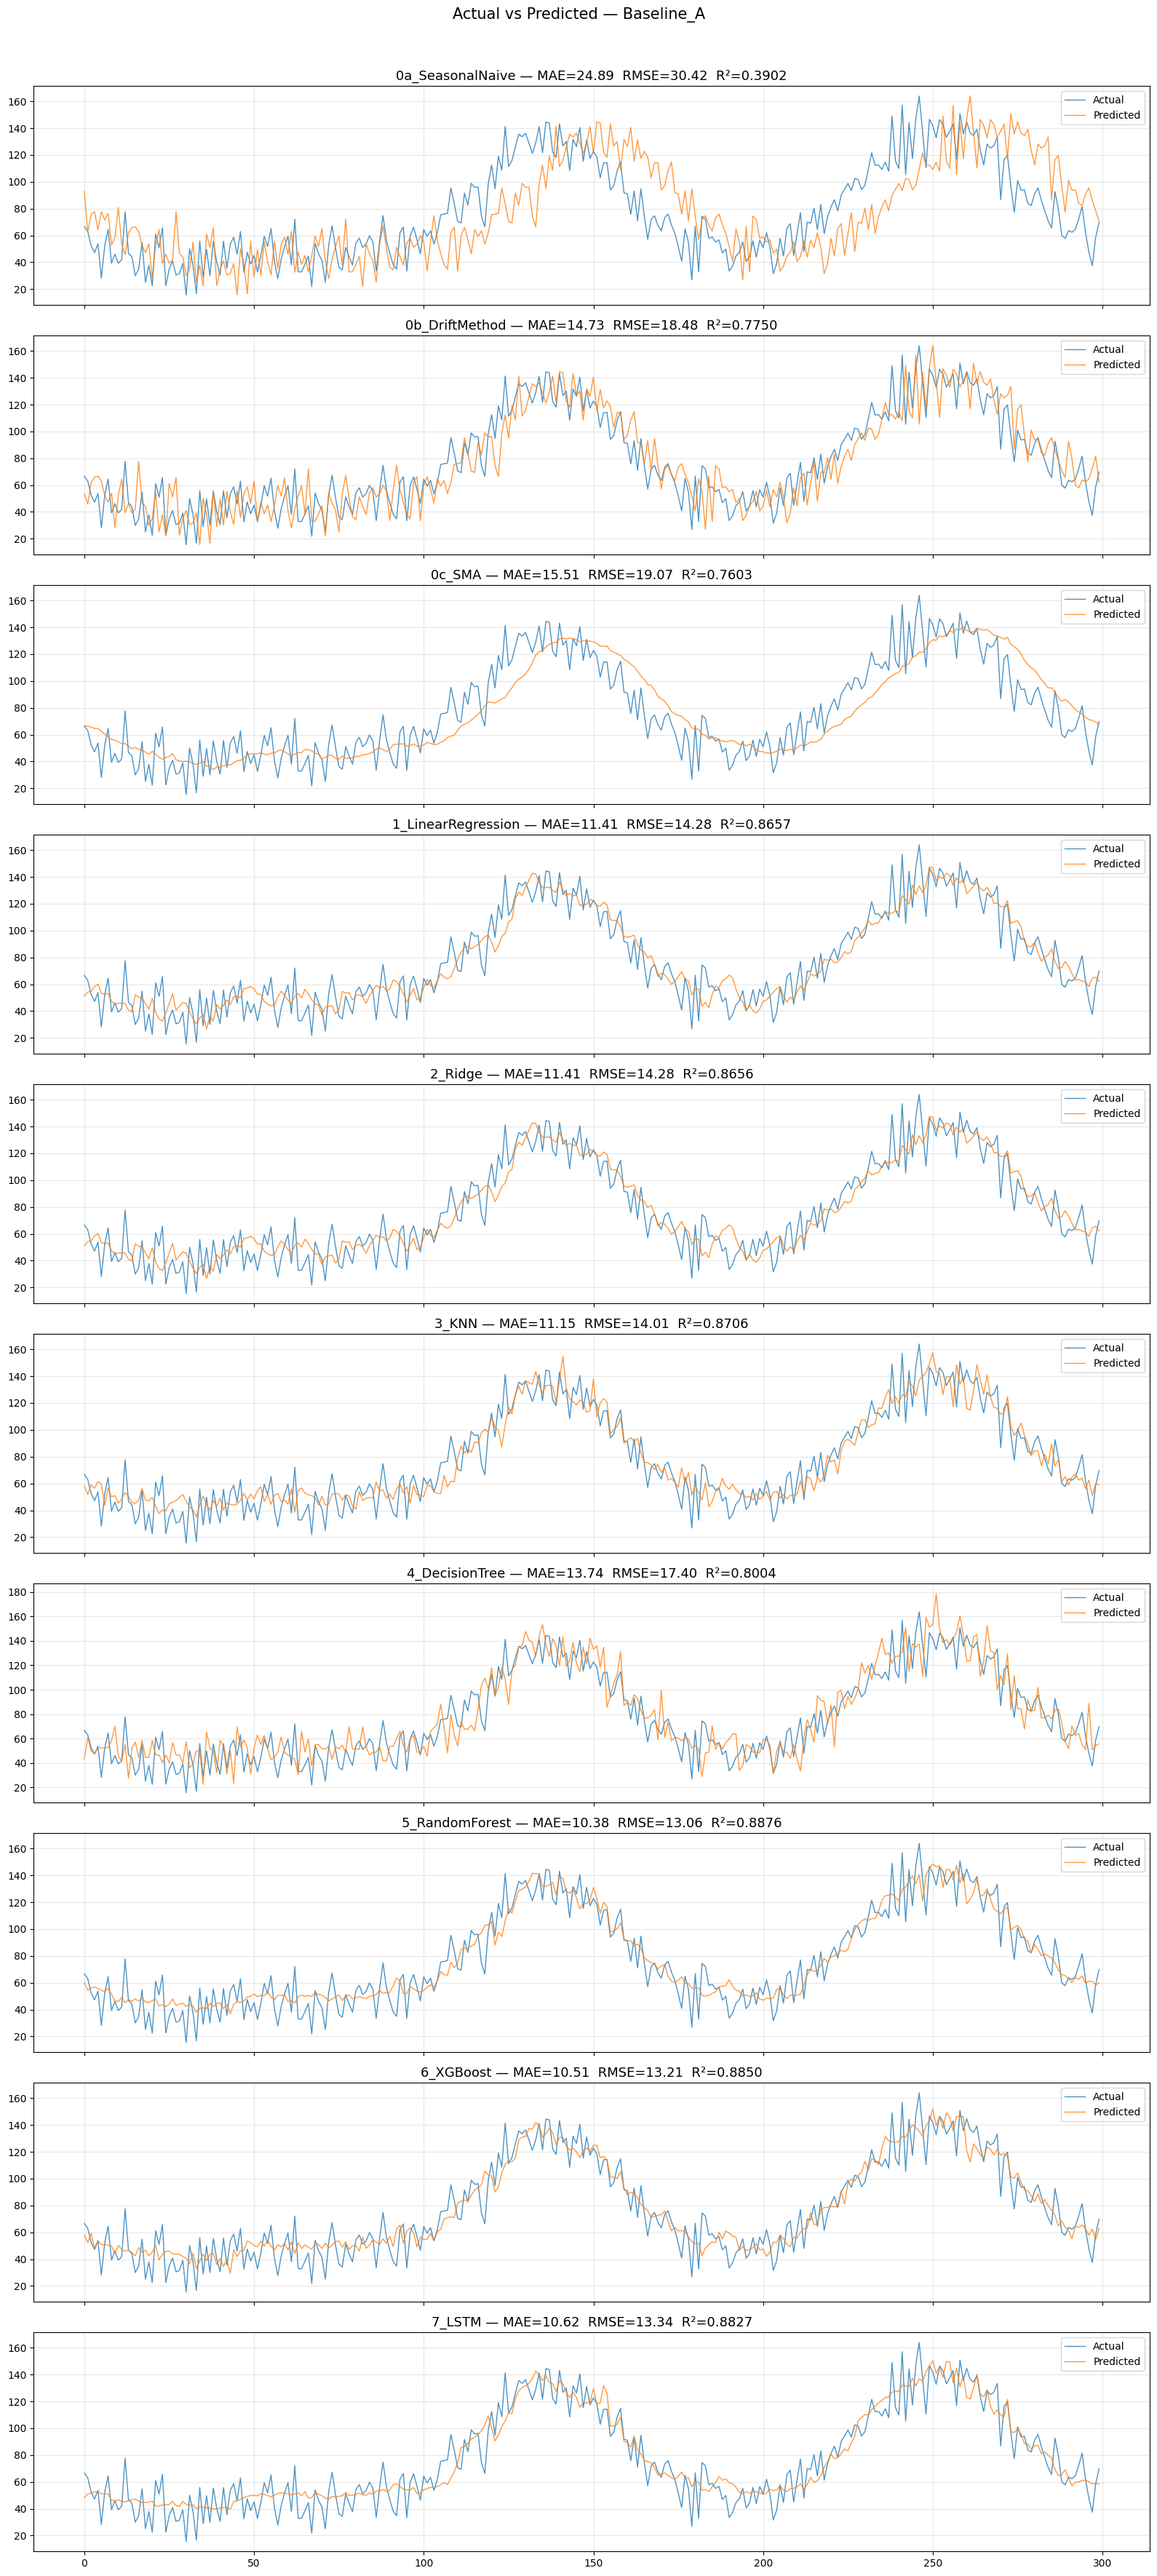

In [23]:
viz.plot_all_model_results(
    trained_a, y_test_a,
    baseline_name='Baseline_A',
    save_dir=CONFIG['images_dir'],
    n_points=300
)

### 5.5. Biểu đồ Actual vs Predicted — Baseline B

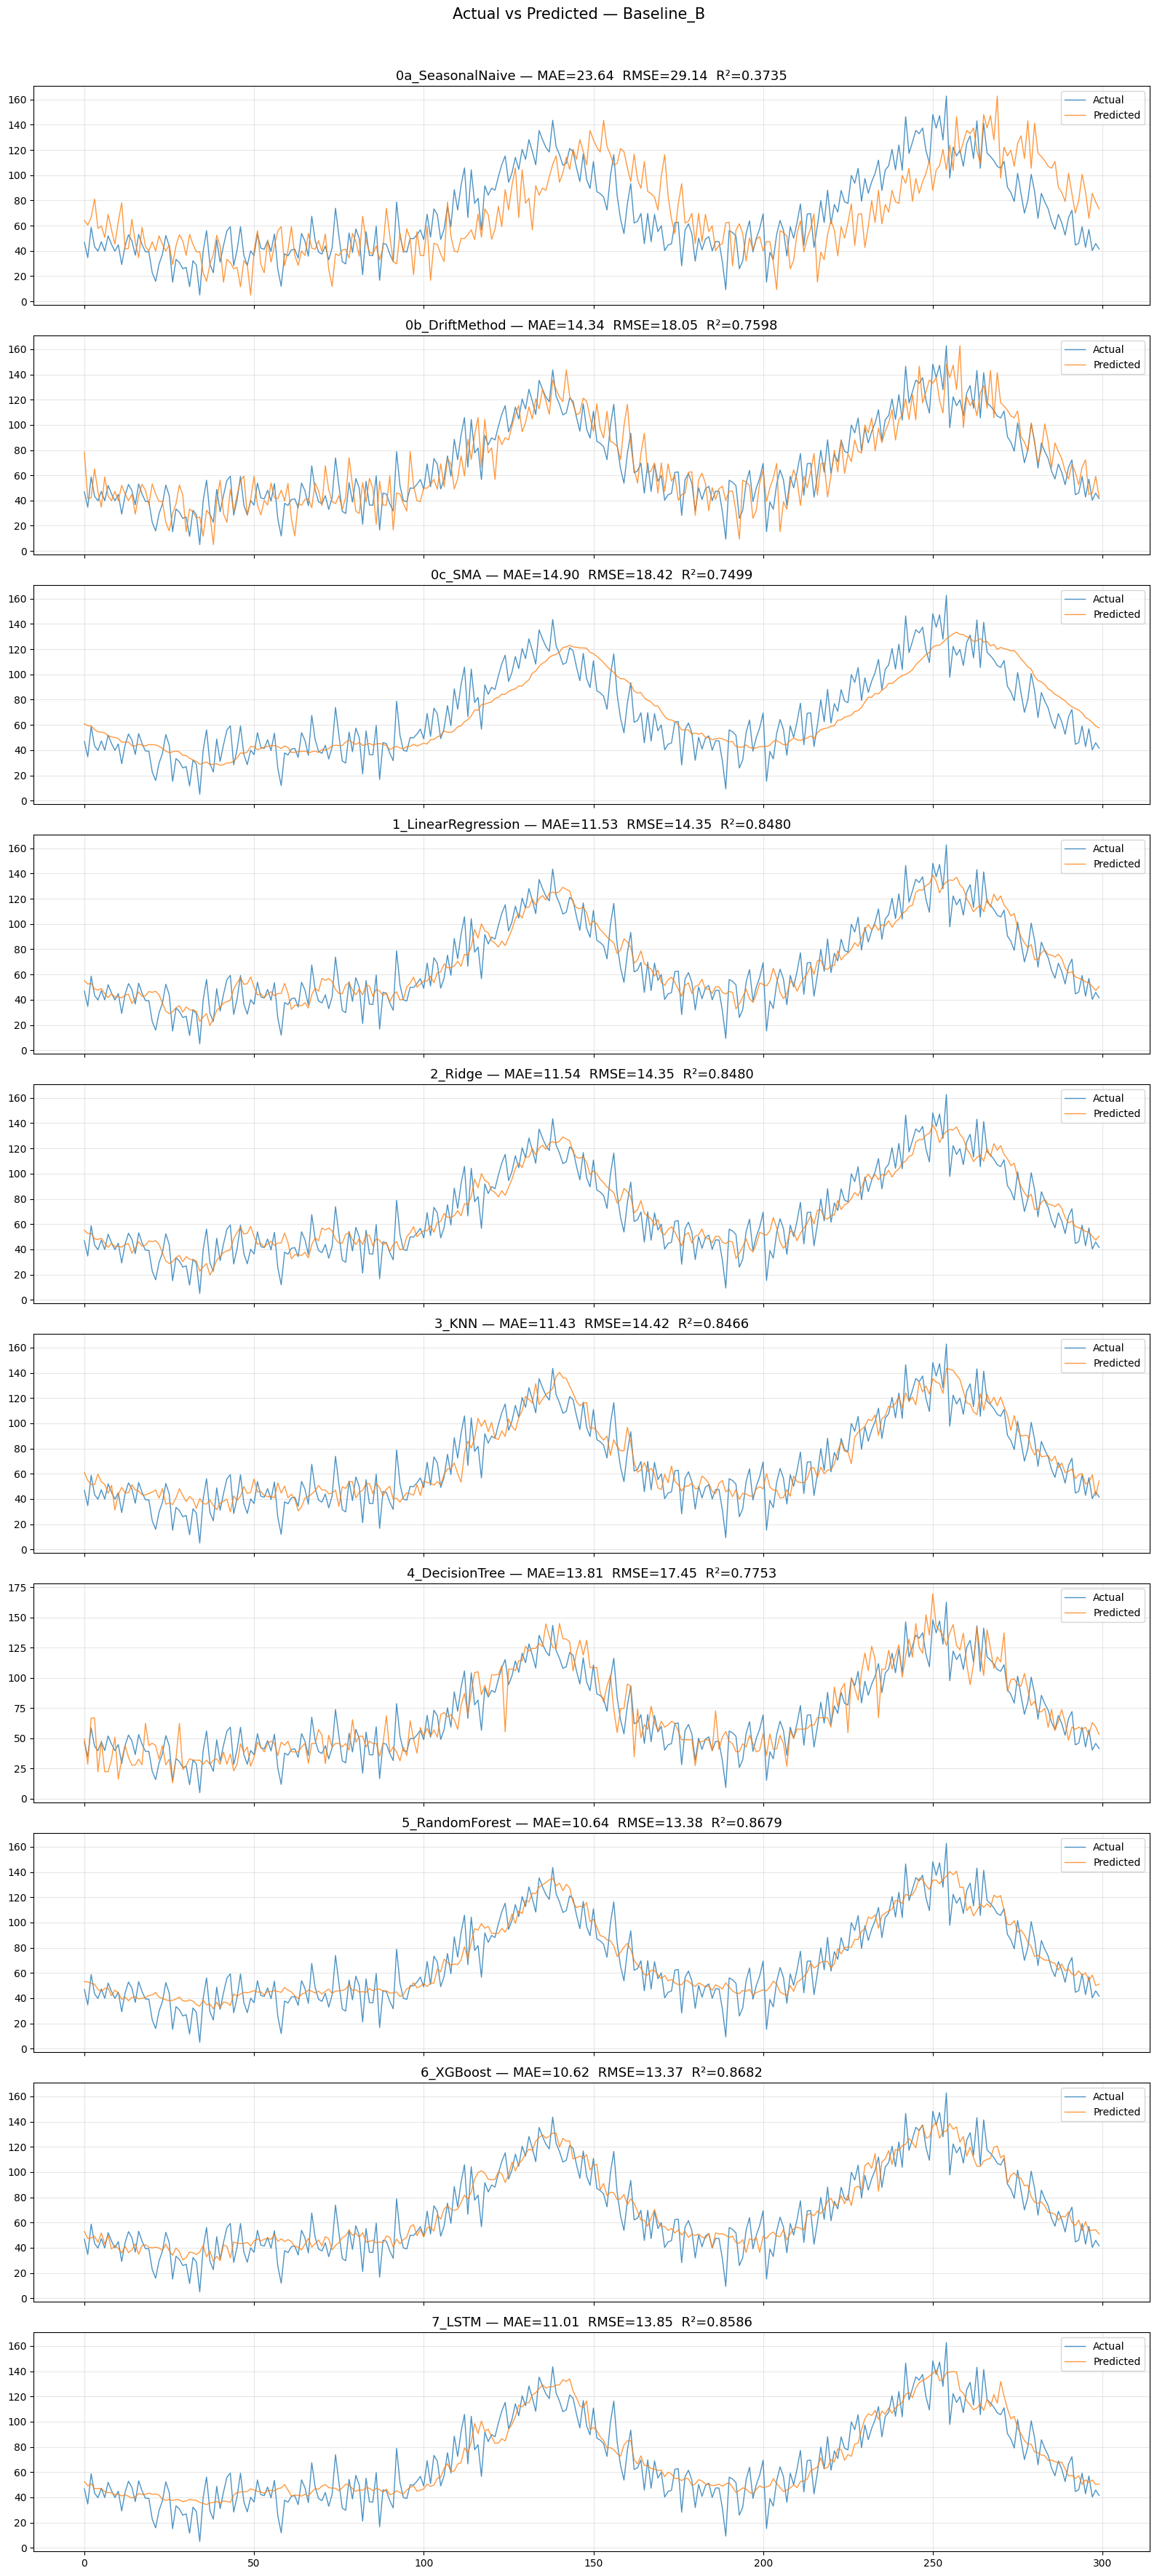

In [24]:
viz.plot_all_model_results(
    trained_b, y_test_b,
    baseline_name='Baseline_B',
    save_dir=CONFIG['images_dir'],
    n_points=300
)

---
## 6. So sánh 2 Baseline

### 6.1. Bảng tổng hợp metrics

In [25]:
compare_table = comparison.create_comparison_table(results_a, results_b)
compare_table

,model,A_MAE,B_MAE,A_RMSE,B_RMSE,A_MAPE,B_MAPE,A_R2,B_R2,A_MASE,B_MASE,better
0,5_RandomForest,10.3849,10.6383,13.0622,13.3811,15.5648,17.8712,0.8876,0.8679,0.7581,0.7821,A
1,6_XGBoost,10.5081,10.6180,13.2118,13.3665,15.7194,17.8084,0.8850,0.8682,0.7671,0.7806,A
2,7_LSTM,10.6163,11.0102,13.3423,13.8480,15.8998,18.2934,0.8827,0.8586,0.7750,0.8094,A
3,3_KNN,11.1509,11.4326,14.0142,14.4237,16.5389,19.1434,0.8706,0.8466,0.8141,0.8405,A
4,1_LinearRegression,11.4111,11.5343,14.2762,14.3542,17.2474,19.3927,0.8657,0.8480,0.8331,0.8480,A
5,2_Ridge,11.4141,11.5353,14.2800,14.3548,17.2441,19.3929,0.8656,0.8480,0.8333,0.8480,A
6,4_DecisionTree,13.7375,13.8130,17.4033,17.4536,20.0445,22.0495,0.8004,0.7753,1.0029,1.0155,A
7,0b_DriftMethod,14.7282,14.3388,18.4780,18.0452,21.3326,23.2295,0.7750,0.7598,1.0752,1.0541,B
8,0c_SMA,15.5128,14.9027,19.0732,18.4151,21.1267,22.8314,0.7603,0.7499,1.1325,1.0956,B
9,0a_SeasonalNaive,24.8910,23.6375,30.4216,29.1442,32.8822,35.0244,0.3902,0.3735,1.8171,1.7378,B


### 6.2. Biểu đồ so sánh

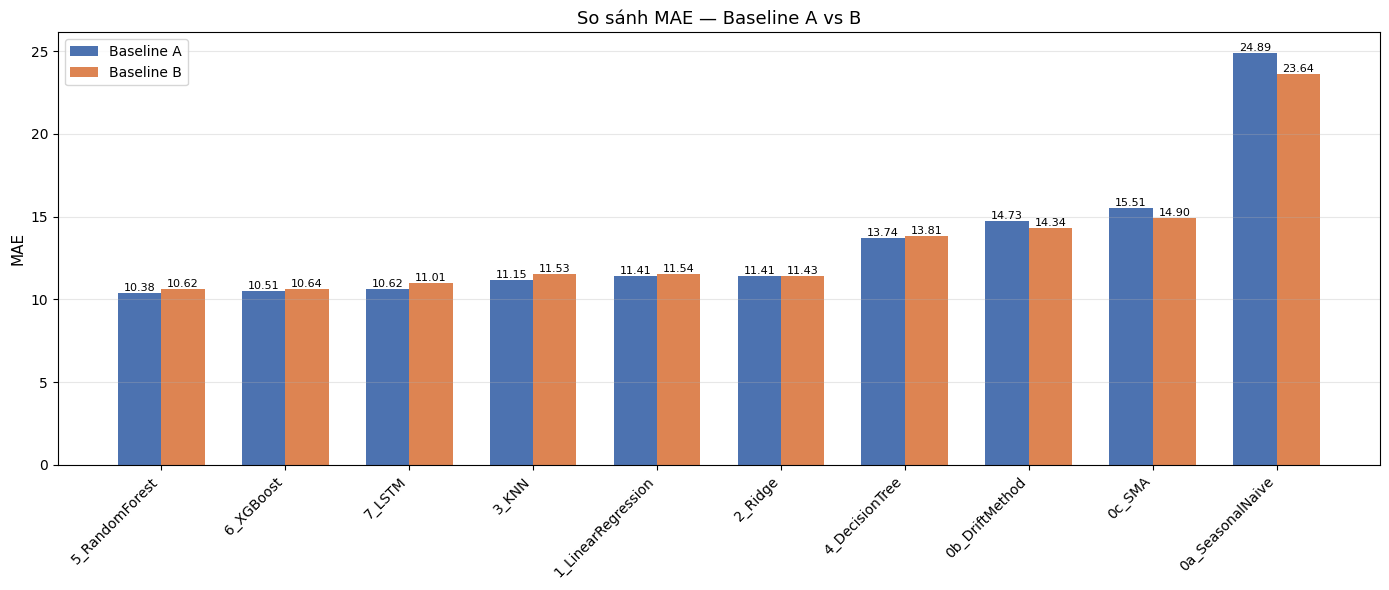

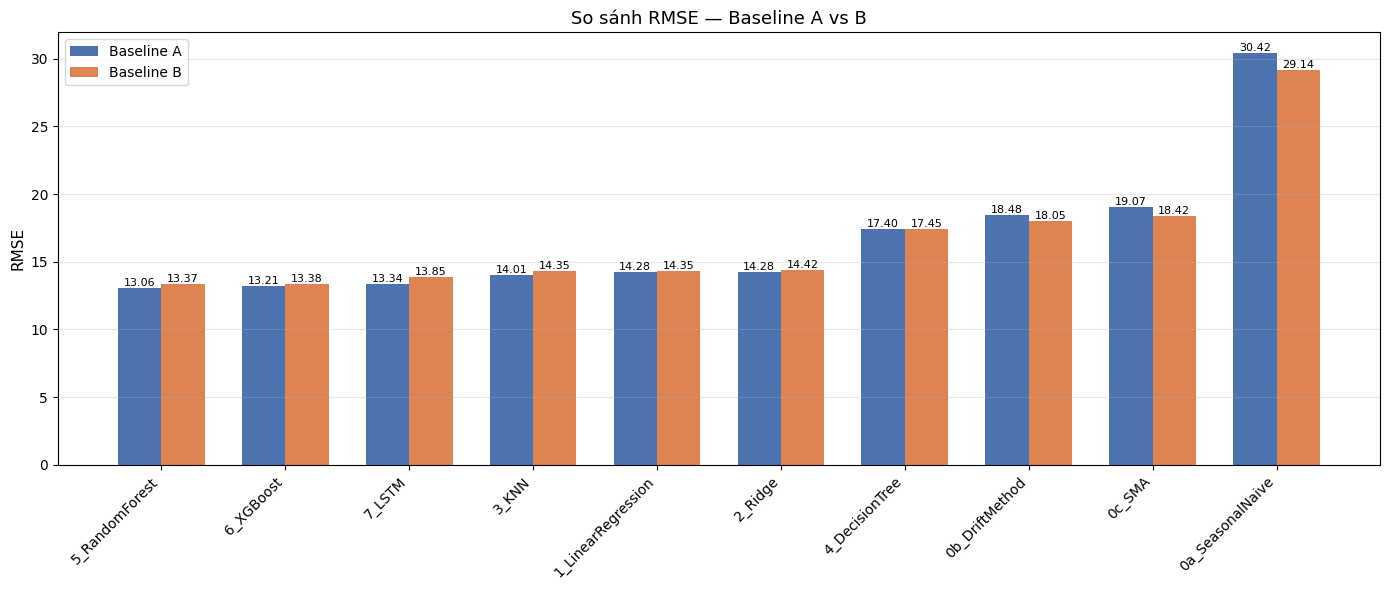

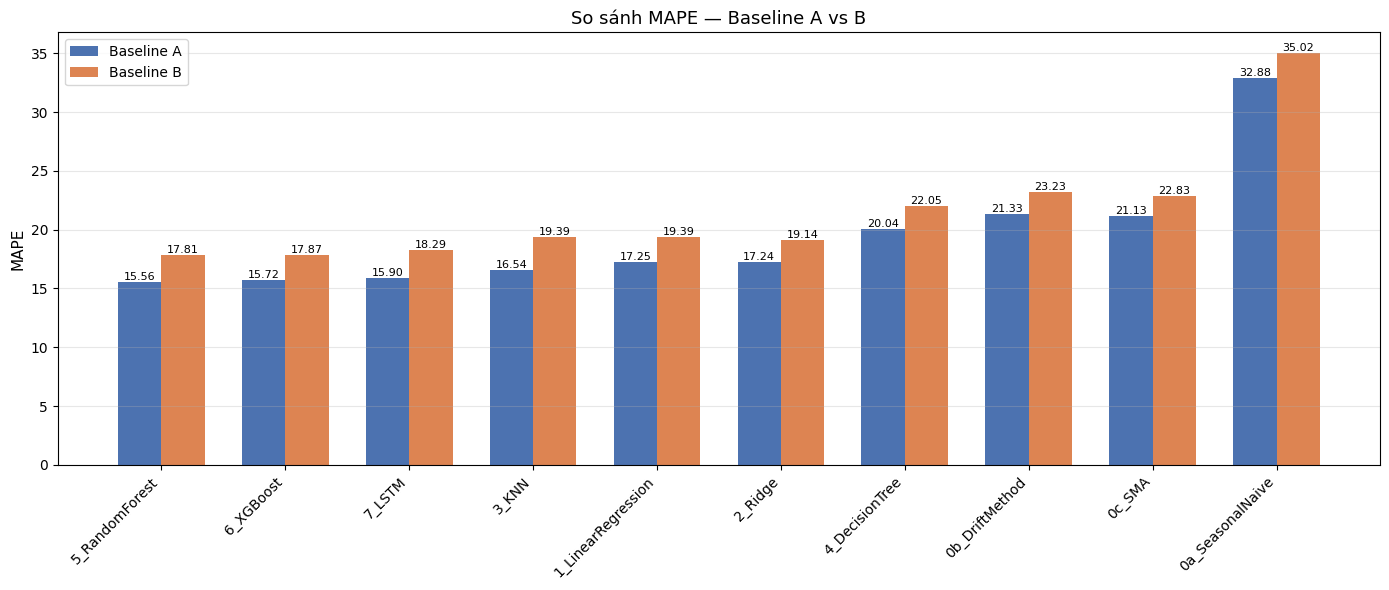

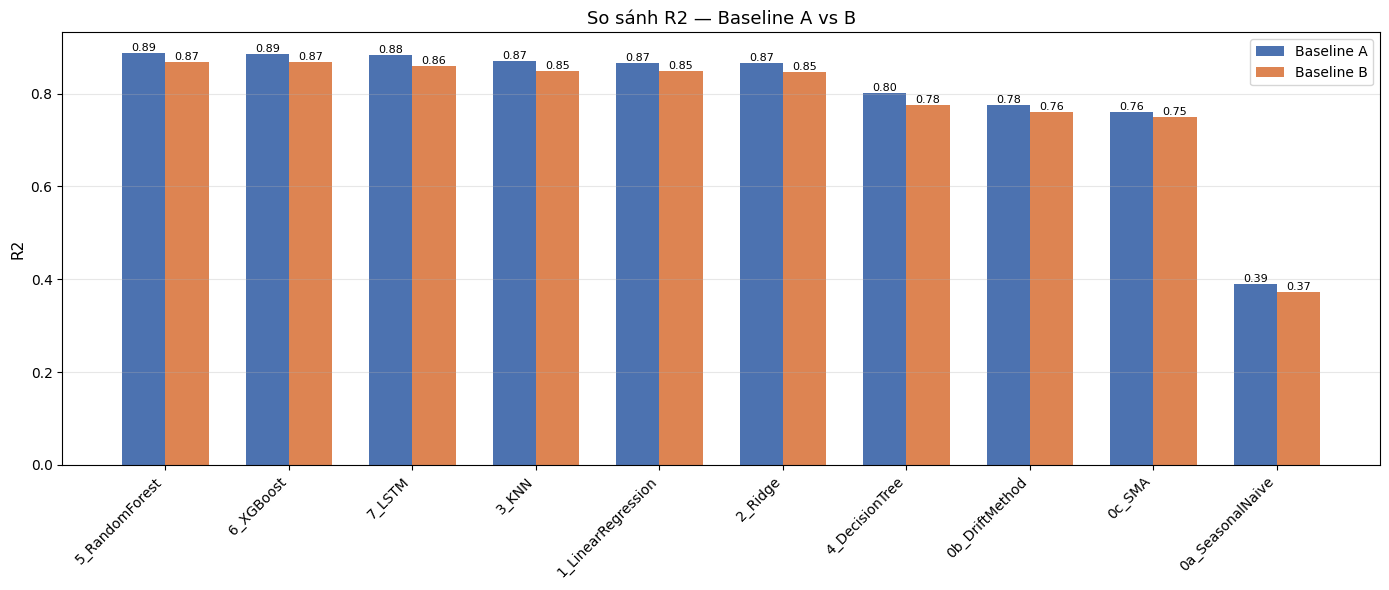

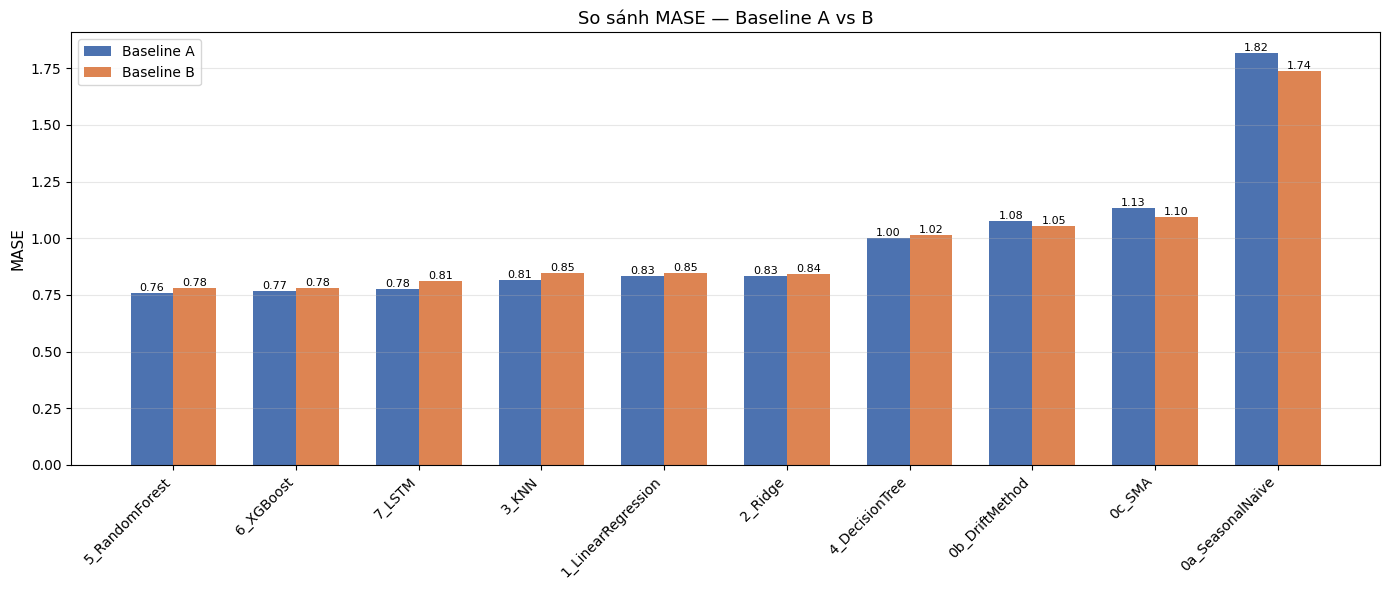

In [26]:
comparison.plot_comparison_all_metrics(
    results_a, results_b,
    save_dir=CONFIG['images_dir']
)

### 6.3. Radar Chart — R²

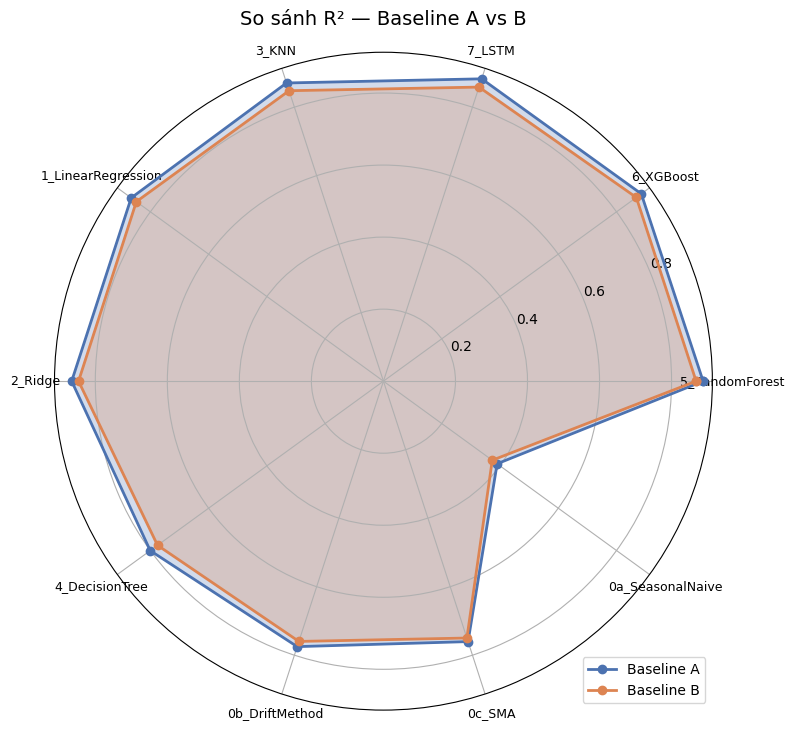

In [27]:
comparison.plot_comparison_radar(
    results_a, results_b,
    save_dir=CONFIG['images_dir']
)

### 6.4. Actual vs Predicted — Mô hình tốt nhất

🏆 Best Baseline A: 5_RandomForest
🏆 Best Baseline B: 6_XGBoost


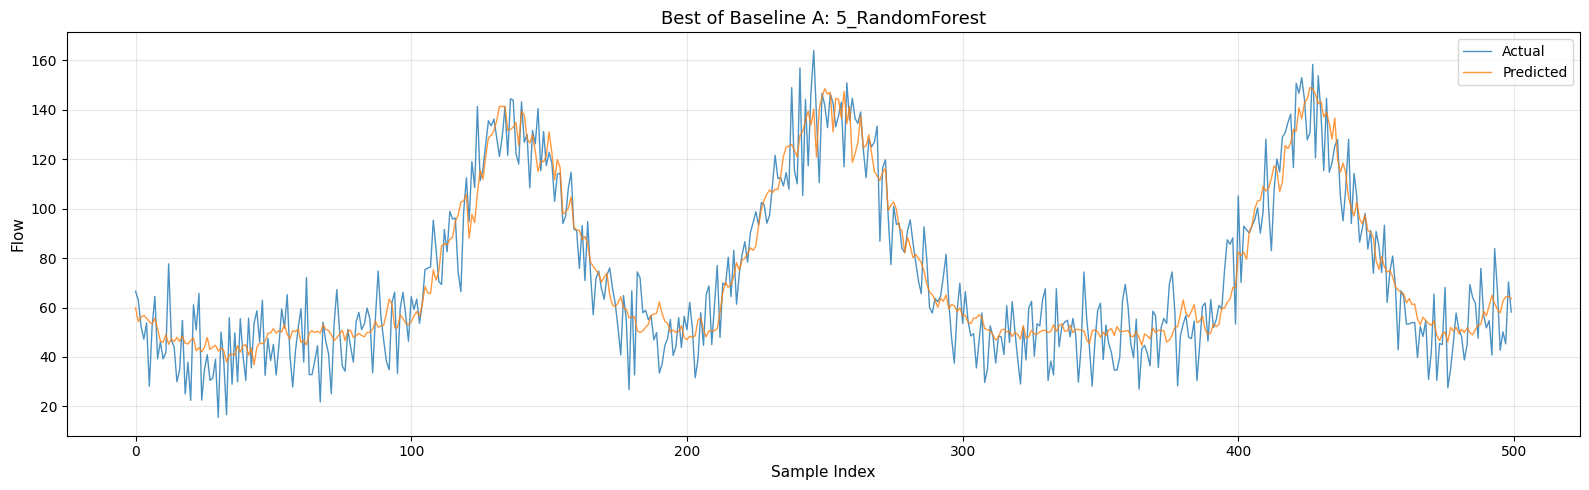

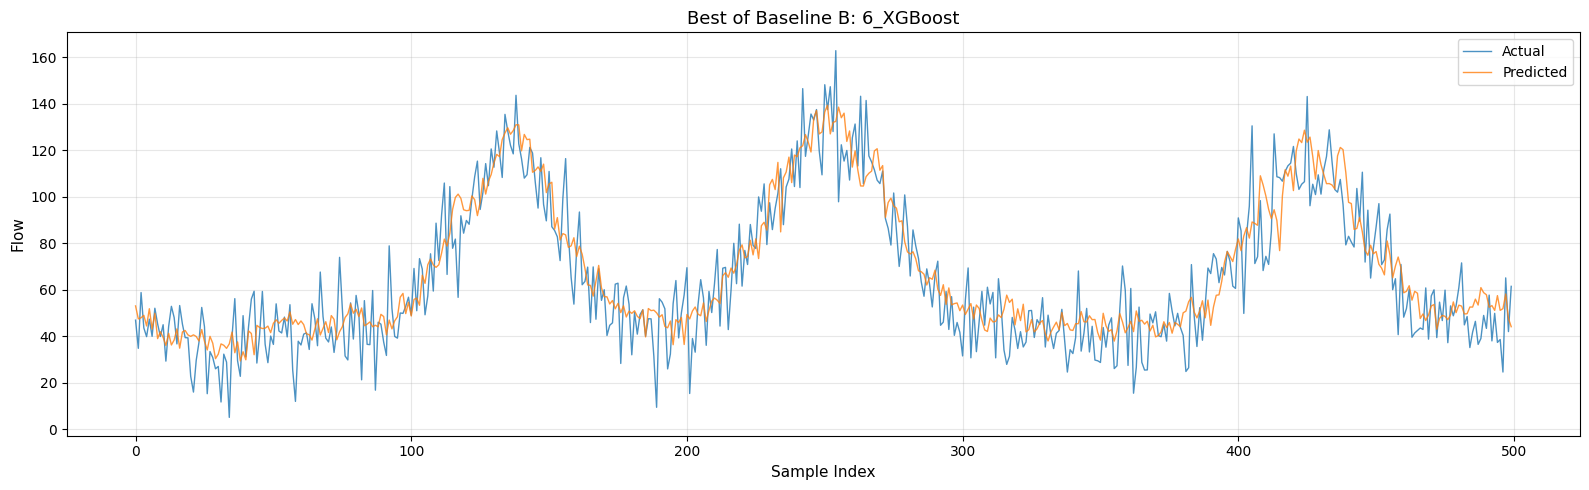

In [28]:
# Tìm mô hình tốt nhất (RMSE thấp nhất) cho mỗi baseline
best_a_name = results_a.loc[results_a['test_RMSE'].idxmin(), 'model']
best_b_name = results_b.loc[results_b['test_RMSE'].idxmin(), 'model']

print(f'🏆 Best Baseline A: {best_a_name}')
print(f'🏆 Best Baseline B: {best_b_name}')

# Vẽ Actual vs Predicted cho mô hình tốt nhất
viz.plot_actual_vs_predicted(
    y_test_a, trained_a[best_a_name]['y_pred_test'],
    title=f'Best of Baseline A: {best_a_name}',
    save_path=f"{CONFIG['images_dir']}/best_A.png"
)
viz.plot_actual_vs_predicted(
    y_test_b, trained_b[best_b_name]['y_pred_test'],
    title=f'Best of Baseline B: {best_b_name}',
    save_path=f"{CONFIG['images_dir']}/best_B.png"
)

### 6.5. Nhận xét & Kết luận

In [29]:
conclusion = comparison.generate_conclusion(results_a, results_b)

📋 NHẬN XÉT & KẾT LUẬN

🏆 Mô hình tốt nhất Baseline A: 5_RandomForest
   RMSE=13.06, MAE=10.38, R²=0.8876

🏆 Mô hình tốt nhất Baseline B: 6_XGBoost
   RMSE=13.37, MAE=10.62, R²=0.8682

📊 RMSE trung bình: A=16.76, B=16.68
   → Baseline B có kết quả dự báo tốt hơn tổng thể.

📝 So sánh chi tiết từng mô hình:
   5_RandomForest: A=13.06 vs B=13.38 → Baseline A tốt hơn (chênh 0.32)
   6_XGBoost: A=13.21 vs B=13.37 → Baseline A tốt hơn (chênh 0.15)
   7_LSTM: A=13.34 vs B=13.85 → Baseline A tốt hơn (chênh 0.51)
   3_KNN: A=14.01 vs B=14.42 → Baseline A tốt hơn (chênh 0.41)
   1_LinearRegression: A=14.28 vs B=14.35 → Baseline A tốt hơn (chênh 0.08)
   2_Ridge: A=14.28 vs B=14.35 → Baseline A tốt hơn (chênh 0.07)
   4_DecisionTree: A=17.40 vs B=17.45 → Baseline A tốt hơn (chênh 0.05)
   0b_DriftMethod: A=18.48 vs B=18.05 → Baseline B tốt hơn (chênh 0.43)
   0c_SMA: A=19.07 vs B=18.42 → Baseline B tốt hơn (chênh 0.66)
   0a_SeasonalNaive: A=30.42 vs B=29.14 → Baseline B tốt hơn (chênh 1.28)


### 6.6. Phân tích lỗi dự báo

Theo phiếu nhiệm vụ, trước khi tối ưu Pymoo cần chỉ ra các trường hợp dự báo sai, nguyên nhân có thể và hướng cải thiện. Phần này dùng mô hình tốt nhất của mỗi baseline trên hold-out test để phân tích residual theo `sensor_id`, `hour` và regime của flow.


In [30]:
# Phân tích lỗi cho mô hình tốt nhất trước Pymoo
error_a = error_analysis.build_error_dataframe(
    test_df=test_a,
    y_true=y_test_a,
    y_pred=trained_a[best_a_name]['y_pred_test'],
    baseline_name='Baseline_A',
    model_name=best_a_name,
)
error_b = error_analysis.build_error_dataframe(
    test_df=test_b,
    y_true=y_test_b,
    y_pred=trained_b[best_b_name]['y_pred_test'],
    baseline_name='Baseline_B',
    model_name=best_b_name,
)

forecast_error_results = error_analysis.combine_error_dataframes([error_a, error_b])
worst_forecasts = error_analysis.get_worst_predictions(forecast_error_results, top_n=20)
sensor_error_summary = error_analysis.summarize_error_segments(
    forecast_error_results,
    group_cols=('baseline', 'model', 'sensor_id'),
)
hour_error_summary = error_analysis.summarize_error_segments(
    forecast_error_results,
    group_cols=('baseline', 'model', 'hour'),
)
flow_regime_error_summary = error_analysis.summarize_error_segments(
    forecast_error_results,
    group_cols=('baseline', 'model', 'flow_regime'),
)
error_cause_table = error_analysis.infer_error_causes(forecast_error_results)

display(worst_forecasts)
display(sensor_error_summary.head(10))
display(hour_error_summary.head(10))
display(flow_regime_error_summary)
display(error_cause_table)

# Lưu bảng lỗi để đưa vào báo cáo
forecast_error_results.to_csv(f"{CONFIG['clean_dir']}/forecast_error_details.csv", index=False)
worst_forecasts.to_csv(f"{CONFIG['clean_dir']}/forecast_error_worst_cases.csv", index=False)
sensor_error_summary.to_csv(f"{CONFIG['clean_dir']}/forecast_error_by_sensor.csv", index=False)
hour_error_summary.to_csv(f"{CONFIG['clean_dir']}/forecast_error_by_hour.csv", index=False)
flow_regime_error_summary.to_csv(f"{CONFIG['clean_dir']}/forecast_error_by_flow_regime.csv", index=False)


,baseline,model,timestamp,sensor_id,hour,weekday,flow_regime,actual,predicted,error,abs_error,ape_%,bias_type
0,Baseline_B,6_XGBoost,2024-02-19 07:20:00,PEMSD3_012,7,0,high_flow,158.90,106.5030,52.3970,52.3970,32.9748,under_predict
1,Baseline_B,6_XGBoost,2024-02-18 20:35:00,PEMSD3_013,20,6,high_flow,99.36,50.7936,48.5664,48.5664,48.8792,under_predict
2,Baseline_B,6_XGBoost,2024-02-19 02:45:00,PEMSD3_012,2,0,high_flow,90.88,44.6392,46.2408,46.2408,50.8811,under_predict
3,Baseline_A,5_RandomForest,2024-02-19 17:15:00,PEMSD3_008,17,0,high_flow,174.35,129.6794,44.6706,44.6706,25.6212,under_predict
4,Baseline_B,6_XGBoost,2024-02-20 16:40:00,PEMSD3_013,16,1,high_flow,188.86,144.2183,44.6417,44.6417,23.6375,under_predict
5,Baseline_A,5_RandomForest,2024-02-21 18:25:00,PEMSD3_010,18,2,high_flow,120.48,164.9545,-44.4745,44.4745,36.9144,over_predict
6,Baseline_B,6_XGBoost,2024-02-19 06:05:00,PEMSD3_011,6,0,medium_flow,56.63,101.0296,-44.3996,44.3996,78.4030,over_predict
7,Baseline_A,5_RandomForest,2024-02-21 09:05:00,PEMSD3_009,9,2,medium_flow,87.11,130.3932,-43.2832,43.2832,49.6879,over_predict
8,Baseline_A,5_RandomForest,2024-02-21 18:35:00,PEMSD3_009,18,2,high_flow,180.98,137.8579,43.1221,43.1221,23.8270,under_predict
9,Baseline_A,5_RandomForest,2024-02-21 15:40:00,PEMSD3_009,15,2,high_flow,143.13,100.0379,43.0921,43.0921,30.1069,under_predict


,baseline,model,sensor_id,n,MAE,RMSE,MAPE_%,bias_mean,actual_mean,predicted_mean,under_predict_%
0,Baseline_B,6_XGBoost,PEMSD3_011,905,11.0412,13.7786,21.8133,-1.7527,69.7582,71.5109,42.6519
1,Baseline_B,6_XGBoost,PEMSD3_013,905,10.8159,13.6279,17.0704,0.2848,81.1964,80.9116,49.6133
2,Baseline_A,5_RandomForest,PEMSD3_009,905,10.5060,13.2866,15.1075,0.4757,87.6260,87.1503,49.1713
3,Baseline_B,6_XGBoost,PEMSD3_014,905,10.4732,13.1800,14.4673,1.9940,88.4606,86.4666,54.6961
4,Baseline_A,5_RandomForest,PEMSD3_007,905,10.4172,13.1537,18.0527,-1.3921,76.9820,78.3741,45.6354
5,Baseline_A,5_RandomForest,PEMSD3_010,905,10.4496,13.1473,13.3154,1.8694,94.6947,92.8253,56.0221
6,Baseline_B,6_XGBoost,PEMSD3_012,905,10.1418,12.8595,17.8828,-0.6683,75.7165,76.3848,48.0663
7,Baseline_A,5_RandomForest,PEMSD3_008,905,10.1669,12.6520,15.7835,-0.3396,82.2506,82.5902,48.5083


,baseline,model,hour,n,MAE,RMSE,MAPE_%,bias_mean,actual_mean,predicted_mean,under_predict_%
0,Baseline_B,6_XGBoost,6,144,12.0588,15.5065,11.7237,0.1910,108.2951,108.1040,47.2222
1,Baseline_A,5_RandomForest,8,144,12.3131,14.9580,9.3587,-1.5912,135.4077,136.9989,46.5278
2,Baseline_B,6_XGBoost,17,144,12.1815,14.8727,8.5429,-0.1389,146.1956,146.3345,46.5278
3,Baseline_A,5_RandomForest,18,144,11.1680,14.7380,8.3743,1.2307,136.4365,135.2058,56.9444
4,Baseline_A,5_RandomForest,16,144,11.5976,14.6943,7.8309,3.6797,148.5481,144.8684,59.7222
5,Baseline_B,6_XGBoost,7,144,11.1438,14.5634,8.5702,1.7790,131.5510,129.7721,55.5556
6,Baseline_B,6_XGBoost,19,144,12.0895,14.5545,13.6744,-2.4814,95.3410,97.8223,46.5278
7,Baseline_B,6_XGBoost,2,144,11.3770,14.4802,27.1223,0.8362,48.8733,48.0371,52.0833
8,Baseline_A,5_RandomForest,17,144,11.2312,14.3177,7.3377,0.3363,156.4241,156.0878,48.6111
9,Baseline_B,6_XGBoost,8,144,11.6912,14.2449,9.6869,-0.4701,124.9418,125.4119,46.5278


,baseline,model,flow_regime,n,MAE,RMSE,MAPE_%,bias_mean,actual_mean,predicted_mean,under_predict_%
0,Baseline_B,6_XGBoost,high_flow,1207,11.3500,14.3693,9.3281,3.1036,124.1523,121.0487,58.5750
1,Baseline_A,5_RandomForest,high_flow,1207,11.0726,13.9610,8.4283,3.1897,133.4504,130.2607,60.2320
2,Baseline_B,6_XGBoost,medium_flow,1206,10.9800,13.5163,15.7626,4.1238,69.8116,65.6878,64.5937
3,Baseline_A,5_RandomForest,medium_flow,1206,10.7058,13.1711,14.1845,4.4189,75.6638,71.2449,65.9204
4,Baseline_B,6_XGBoost,low_flow,1207,9.5244,12.1170,28.3330,-7.3306,42.3774,49.7080,23.1152
5,Baseline_A,5_RandomForest,low_flow,1207,9.3766,11.9781,24.0804,-7.1451,47.0427,54.1877,23.3637


,case,n_cases,MAE,possible_cause,improvement
0,High-flow underestimated,558,14.1590,"Giai doan flow cao/cao diem co bien dong manh,...","Tang trong so mau high-flow, them lag dai hon/..."
1,Low-flow overestimated,712,15.8054,Dem/khoang giao thong thap co pattern khac voi...,"Them interaction hour x lag, tach weekday/week..."
2,Abrupt flow change,295,29.1226,"Flow thay doi dot ngot so voi lag gan nhat, ca...","Them delta/acceleration features, rolling tren..."
3,Worst hour segment: hour=6,144,12.0588,"Mot khung gio co pattern flow/speed rieng, co ...","Kiem tra SHAP theo hour, them cyclic encoding ..."


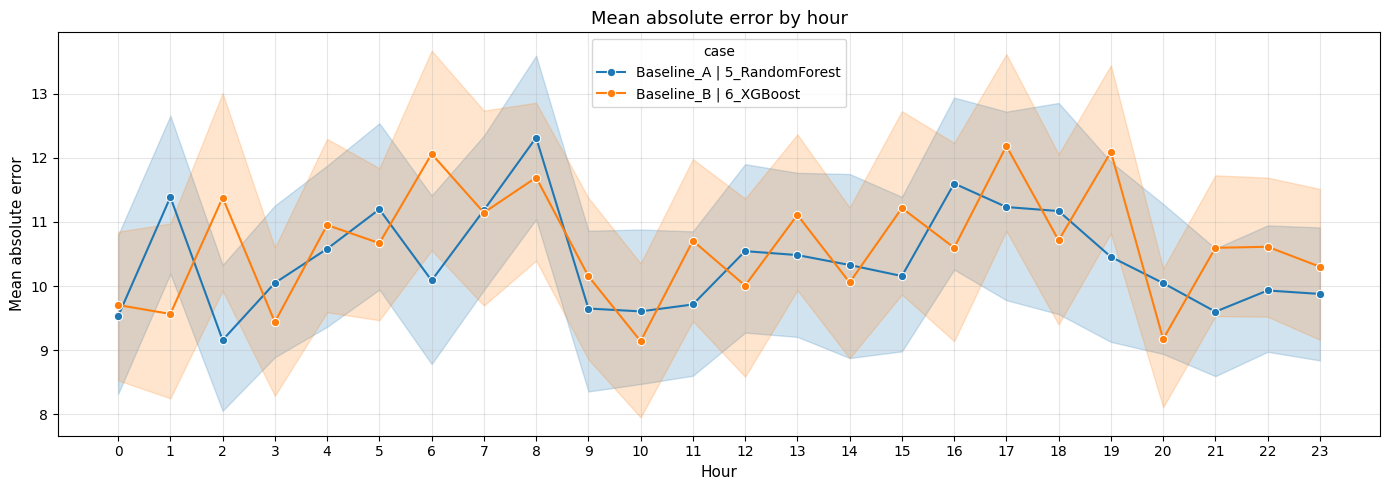

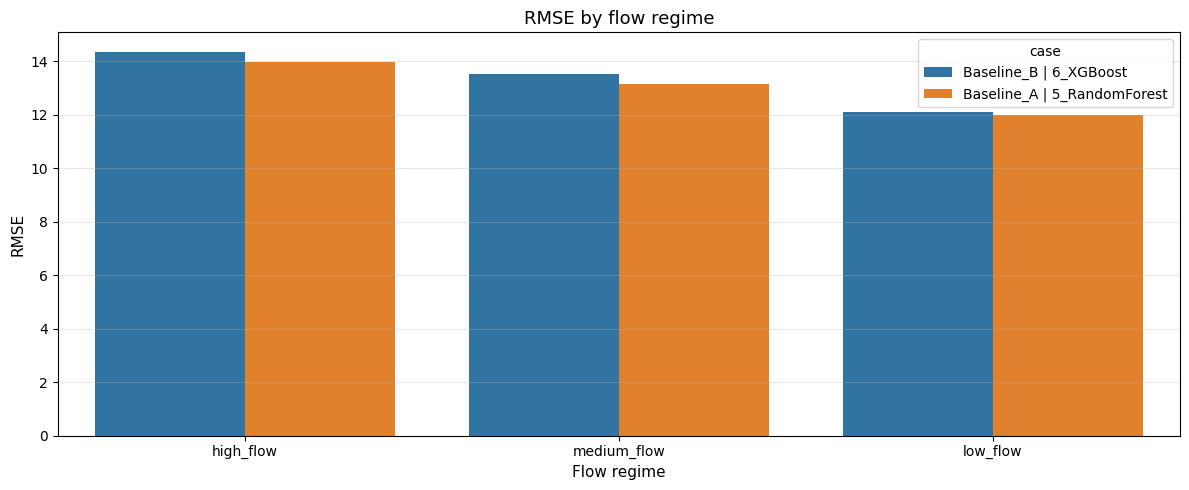

In [31]:
error_analysis.plot_error_by_hour(
    forecast_error_results,
    save_path=f"{CONFIG['images_dir']}/error_analysis_by_hour.png",
)
error_analysis.plot_error_by_flow_regime(
    forecast_error_results,
    save_path=f"{CONFIG['images_dir']}/error_analysis_by_flow_regime.png",
)


Diễn giải nhanh cho báo cáo: các dòng trong `worst_forecasts` là các điểm dự báo sai nhất; `sensor_error_summary` cho biết sensor nào khó dự báo; `hour_error_summary` chỉ ra khung giờ có lỗi cao; `flow_regime_error_summary` kiểm tra mô hình sai nhiều ở flow thấp/trung bình/cao. Bảng `error_cause_table` gom các nguyên nhân có thể và hướng cải thiện để đưa thẳng vào phần nhận xét/hạn chế.


---
## 7. Tối ưu hóa đa mục tiêu siêu tham số (Pymoo)

Sau khi so sánh 2 baseline, chọn **2 mô hình tốt nhất** (có RMSE tốt trên cả 2 baseline)
để tối ưu hóa siêu tham số bằng bài toán **đa mục tiêu**.

**3 mục tiêu (tất cả minimize):**
1. **RMSE** — Chất lượng dự báo
2. **Search time** — Thời gian huấn luyện
3. **Model complexity** — Độ phức tạp mô hình

**Thuật toán:** NSGA-II (hoặc NSGA-III nếu cần)

### 7.1. Chọn 2 mô hình tốt nhất

In [32]:
from modules import optimization as optim

# Chọn 2 mô hình có RMSE trung bình tốt nhất trên cả 2 baselines.
# Với kết quả hiện tại của bài, hàm này chọn 6_XGBoost và 5_RandomForest.
best_model_names = optim.select_best_models(results_a, results_b, top_n=2)
current_expected_models = {'6_XGBoost', '5_RandomForest'}
if set(best_model_names) == current_expected_models:
    print('✅ Kết quả hiện tại: 2 mô hình tốt nhất là 6_XGBoost và 5_RandomForest.')
else:
    print('⚠️ Kết quả hiện tại khác mô tả ban đầu, notebook sẽ dùng kết quả được chọn từ RMSE:')
print(f'Sẽ tối ưu hóa: {best_model_names}')

optimized_cases = [
    {'baseline': baseline_name, 'model': model_name, 'case': f'{baseline_name} | {model_name}'}
    for baseline_name in ['Baseline_A', 'Baseline_B']
    for model_name in best_model_names
]
display(pd.DataFrame(optimized_cases))


🏆 Top 2 mô hình tốt nhất trên CẢ HAI baselines:
   5_RandomForest: A_RMSE=13.0622, B_RMSE=13.3811, Avg=13.2217
   6_XGBoost: A_RMSE=13.2118, B_RMSE=13.3665, Avg=13.2891
✅ Kết quả hiện tại: 2 mô hình tốt nhất là 6_XGBoost và 5_RandomForest.
Sẽ tối ưu hóa: ['5_RandomForest', '6_XGBoost']


,baseline,model,case
0,Baseline_A,5_RandomForest,Baseline_A | 5_RandomForest
1,Baseline_A,6_XGBoost,Baseline_A | 6_XGBoost
2,Baseline_B,5_RandomForest,Baseline_B | 5_RandomForest
3,Baseline_B,6_XGBoost,Baseline_B | 6_XGBoost


### 7.2. Cấu hình tối ưu hóa

In [33]:
from configs.configs import OPTIM_CONFIG
print(f'✅ OPTIM_CONFIG: {OPTIM_CONFIG}')

✅ OPTIM_CONFIG: {'pop_size': 300, 'n_gen': 100, 'algorithm': 'nsga2', 'random_state': 69}


### 7.3. Chạy tối ưu hóa — Baseline A

In [34]:
pareto_results_a = {}

for model_name in best_model_names:
    print(f'\n{"="*60}')
    print(f'🔍 Tối ưu {model_name} trên Baseline A')
    print(f'{"="*60}')
    
    result, pareto_df, problem = optim.run_optimization(
        model_name = model_name,
        X_train = X_train_a, 
        y_train = y_train_a,
        X_valid = X_valid_a, 
        y_valid = y_valid_a,
        **OPTIM_CONFIG,
        train_subsample_ratio = 1.0,
        baseline_tag = 'A'
    )

    pareto_results_a[model_name] = {
        'result': result,
        'pareto_df': pareto_df,
        'problem': problem,
    }
        
    # Hiển thị top 10 nghiệm Pareto (sắp xếp theo RMSE)
    print(f'\n📋 Top 10 nghiệm Pareto ({model_name}):')
    display(pareto_df.head(10))


🔍 Tối ưu 5_RandomForest trên Baseline A

✅ Checkpoint cho 5_RandomForest [A] đã hoàn tất 101/100 thế hệ. Không cần chạy lại.

✅ Tối ưu hóa hoàn tất trong 55155.8s
   Số nghiệm Pareto: 90
   RMSE range: [13.1261, 14.9723]
   Time range: [5.4659s, 41.1745s]

📋 Top 10 nghiệm Pareto (5_RandomForest):


,n_gen,n_estimators,max_depth,min_samples_split,min_samples_leaf,RMSE,train_time_s,complexity
0,64,130,12,20,1,13.1261,36.5457,1560.0
1,64,127,12,20,1,13.1265,41.1745,1524.0
2,64,126,12,20,1,13.1269,34.9464,1512.0
3,64,125,12,20,1,13.1271,35.4707,1500.0
4,64,130,11,20,1,13.1276,32.0536,1430.0
5,64,127,11,20,1,13.1279,33.0447,1397.0
6,64,126,11,20,1,13.1286,32.8369,1386.0
7,64,125,11,20,1,13.1291,37.4985,1375.0
8,64,115,12,20,1,13.1297,33.4800,1380.0
9,63,114,12,20,1,13.1301,39.4630,1368.0



🔍 Tối ưu 6_XGBoost trên Baseline A

✅ Checkpoint cho 6_XGBoost [A] đã hoàn tất 101/100 thế hệ. Không cần chạy lại.

✅ Tối ưu hóa hoàn tất trong 3427.7s
   Số nghiệm Pareto: 117
   RMSE range: [12.6890, 12.9914]
   Time range: [0.3573s, 1.2146s]

📋 Top 10 nghiệm Pareto (6_XGBoost):


,n_gen,n_estimators,max_depth,learning_rate,subsample,colsample_bytree,reg_alpha,reg_lambda,RMSE,train_time_s,complexity
0,79,162,3,0.177464,0.898611,0.831690,8.883969,5.121445,12.6890,1.1140,486.0
1,98,105,3,0.181722,0.900854,0.941635,3.675371,0.725724,12.6948,1.2146,315.0
2,95,115,3,0.181468,0.900862,0.931594,3.932845,0.730305,12.6957,0.7421,345.0
3,98,112,3,0.181481,0.900862,0.927423,3.655402,0.695535,12.6959,0.9648,336.0
4,98,114,3,0.181474,0.900855,0.931283,3.559945,0.730298,12.6974,0.8059,342.0
5,84,114,3,0.181477,0.900854,0.931668,3.559945,0.730298,12.6974,0.7109,342.0
6,86,109,3,0.181729,0.900854,0.930003,3.592222,0.730298,12.6981,0.8778,327.0
7,97,110,3,0.181726,0.900853,0.920307,3.509373,0.730298,12.6981,0.7525,330.0
8,99,102,3,0.181726,0.900853,0.920307,3.509373,0.730298,12.6997,0.9828,306.0
9,97,109,3,0.181730,0.900862,0.927879,3.513249,0.725472,12.7033,0.7534,327.0


### 7.4. Chạy tối ưu hóa — Baseline B

In [35]:
pareto_results_b = {}

for model_name in best_model_names:
    print(f'\n{"="*60}')
    print(f'🔍 Tối ưu {model_name} trên Baseline B')
    print(f'{"="*60}')
    
    result, pareto_df, problem = optim.run_optimization(
        model_name = model_name,
        X_train = X_train_b, 
        y_train = y_train_b,
        X_valid = X_valid_b, 
        y_valid = y_valid_b,
        **OPTIM_CONFIG,
        train_subsample_ratio = 1.0,
        baseline_tag = 'B'
    )
    pareto_results_b[model_name] = {
        'result': result,
        'pareto_df': pareto_df,
        'problem': problem,
    }
    
    print(f'\n📋 Top 10 nghiệm Pareto ({model_name}):')
    display(pareto_df.head(10))


🔍 Tối ưu 5_RandomForest trên Baseline B

✅ Checkpoint cho 5_RandomForest [B] đã hoàn tất 101/100 thế hệ. Không cần chạy lại.

✅ Tối ưu hóa hoàn tất trong 519541.8s
   Số nghiệm Pareto: 89
   RMSE range: [13.0421, 14.5970]
   Time range: [6.3895s, 43.8549s]

📋 Top 10 nghiệm Pareto (5_RandomForest):


,n_gen,n_estimators,max_depth,min_samples_split,min_samples_leaf,RMSE,train_time_s,complexity
0,84,143,10,18,5,13.0421,35.4952,1430.0
1,84,142,10,18,5,13.0431,35.9722,1420.0
2,85,141,10,18,5,13.0431,37.8232,1410.0
3,85,140,10,18,5,13.0436,39.4803,1400.0
4,85,139,10,18,5,13.0451,37.7560,1390.0
5,83,141,10,19,5,13.0452,36.9985,1410.0
6,85,138,10,18,5,13.0464,43.8549,1380.0
7,85,138,10,17,5,13.0466,35.2163,1380.0
8,85,134,10,18,5,13.0471,34.5773,1340.0
9,85,101,10,18,5,13.0476,32.8512,1010.0



🔍 Tối ưu 6_XGBoost trên Baseline B

✅ Checkpoint cho 6_XGBoost [B] đã hoàn tất 101/100 thế hệ. Không cần chạy lại.

✅ Tối ưu hóa hoàn tất trong 4025.5s
   Số nghiệm Pareto: 115
   RMSE range: [12.5490, 12.8196]
   Time range: [0.3912s, 1.6995s]

📋 Top 10 nghiệm Pareto (6_XGBoost):


,n_gen,n_estimators,max_depth,learning_rate,subsample,colsample_bytree,reg_alpha,reg_lambda,RMSE,train_time_s,complexity
0,78,159,3,0.188498,0.961760,0.643028,9.645168,7.228804,12.5490,1.4592,477.0
1,76,159,3,0.188495,0.961760,0.640415,9.654124,7.223636,12.5490,1.3988,477.0
2,90,159,3,0.188496,0.961762,0.640494,9.638108,7.228496,12.5490,1.5864,477.0
3,95,159,3,0.188549,0.961760,0.645119,9.645168,7.228804,12.5491,1.0589,477.0
4,86,159,3,0.188547,0.961759,0.645248,9.651582,7.230004,12.5491,1.2919,477.0
5,92,134,3,0.184822,0.964382,0.635583,9.487574,6.008389,12.5503,1.4856,402.0
6,96,134,3,0.184822,0.964382,0.635583,9.755400,6.008389,12.5503,1.5375,402.0
7,67,157,3,0.188553,0.961759,0.646128,9.655111,7.228504,12.5513,1.0692,471.0
8,93,156,3,0.188531,0.961760,0.659434,9.655111,7.228504,12.5517,1.2433,468.0
9,54,151,3,0.188549,0.961760,0.646069,9.655111,7.228504,12.5542,0.9895,453.0


### 7.5. Trực quan hóa Pareto Front


--- Pareto Front: 5_RandomForest ---

📊 Baseline A:


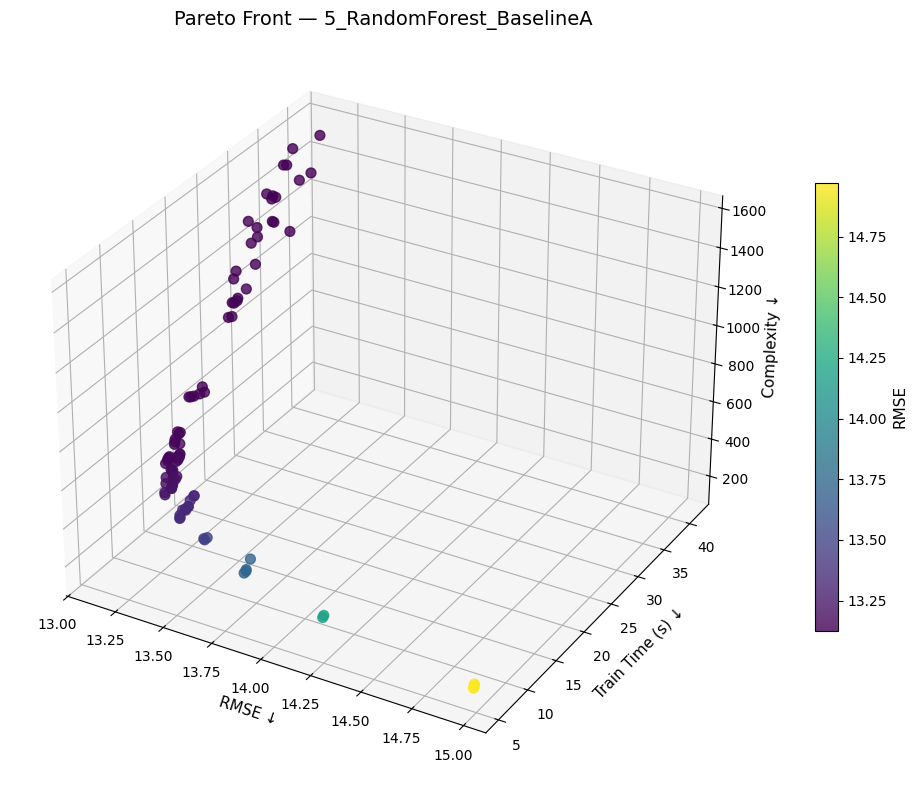

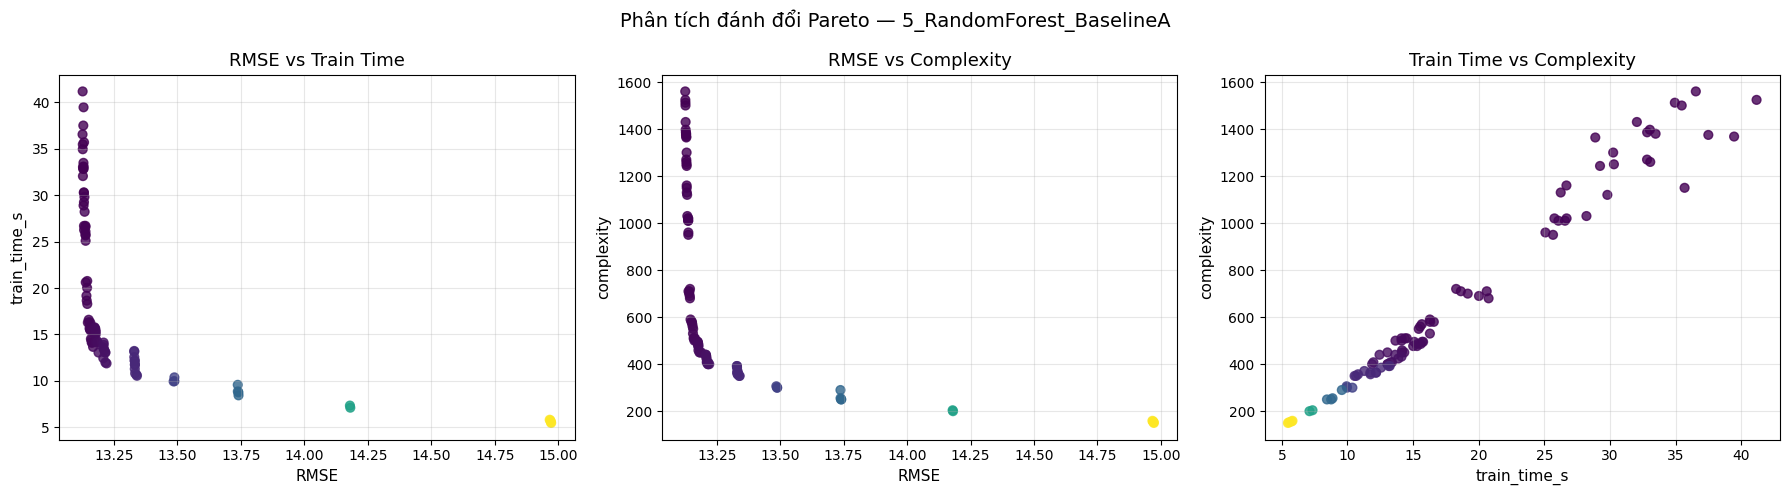


📊 Baseline B:


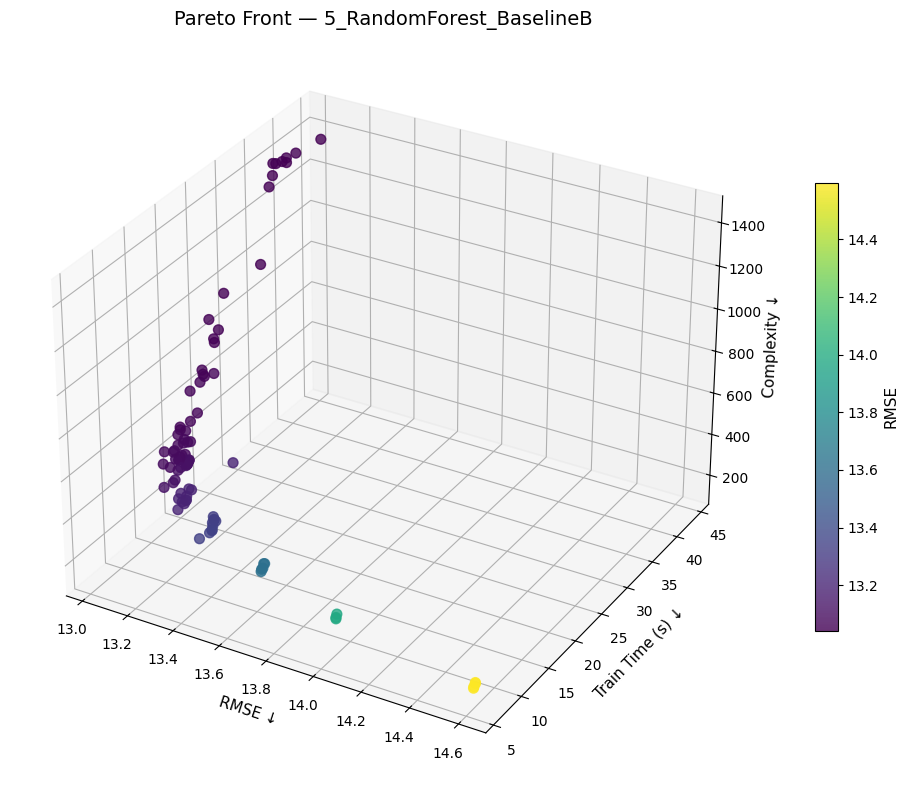

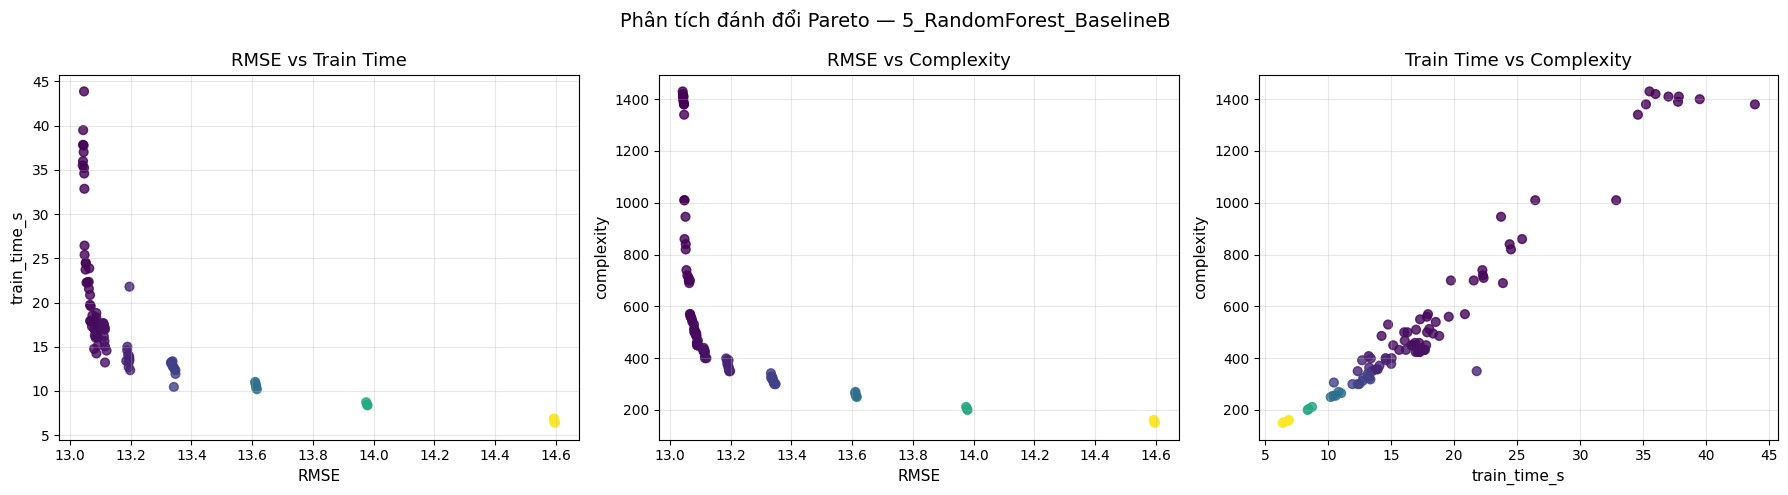


--- Pareto Front: 6_XGBoost ---

📊 Baseline A:


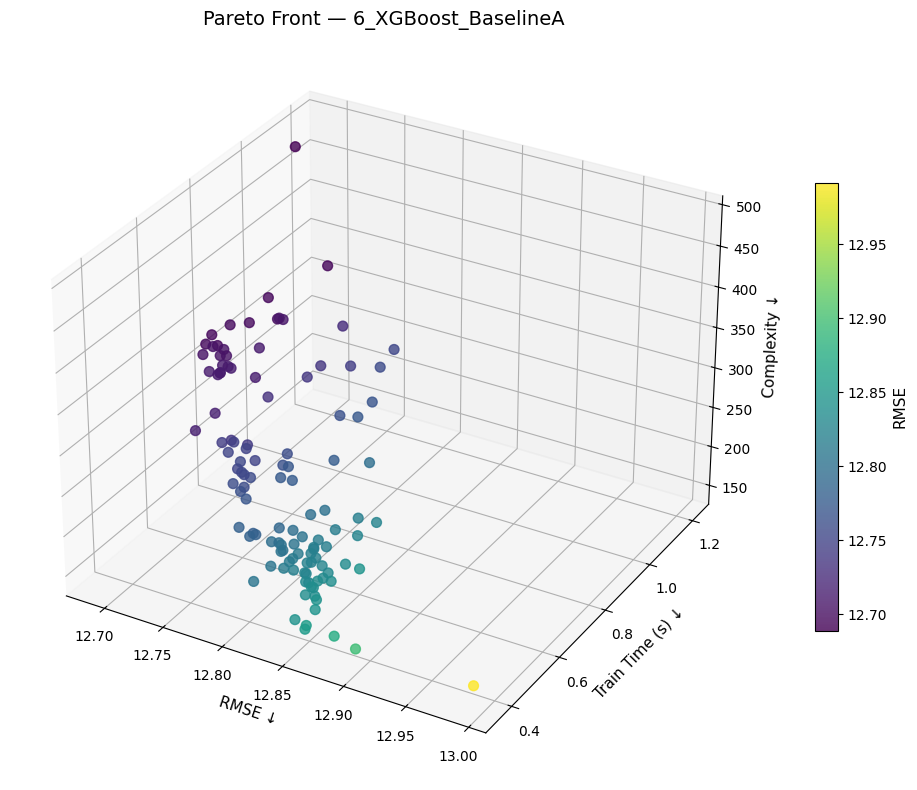

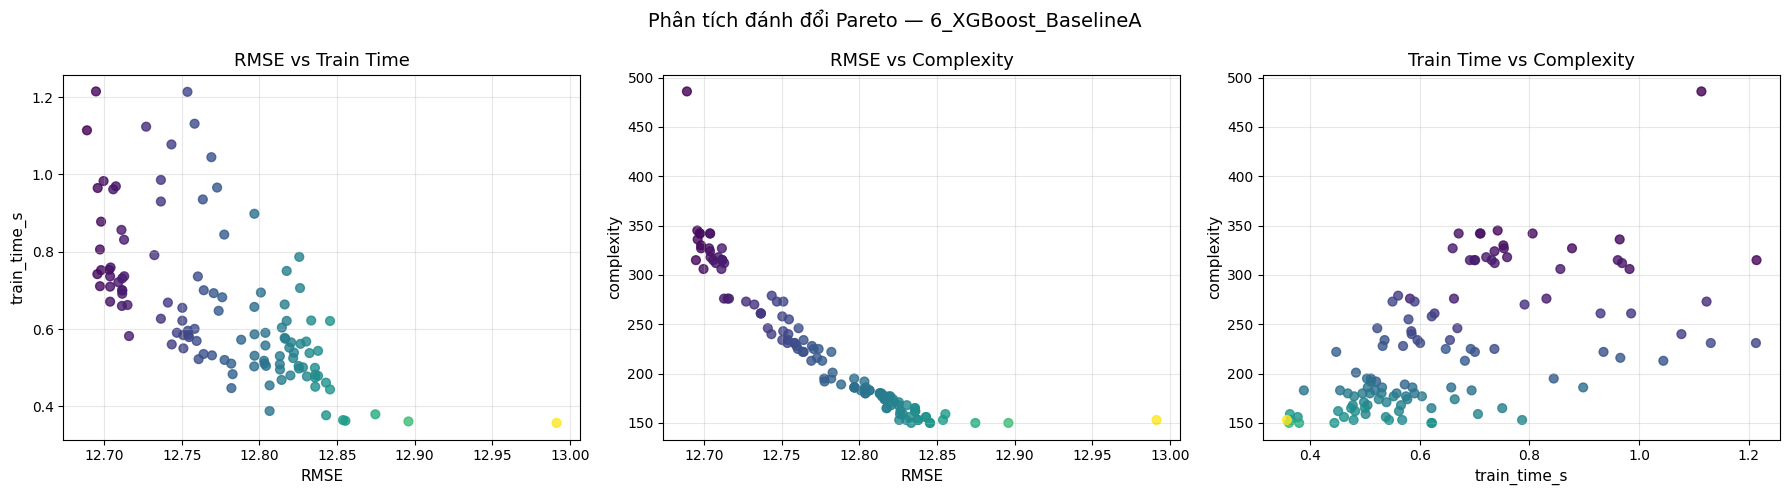


📊 Baseline B:


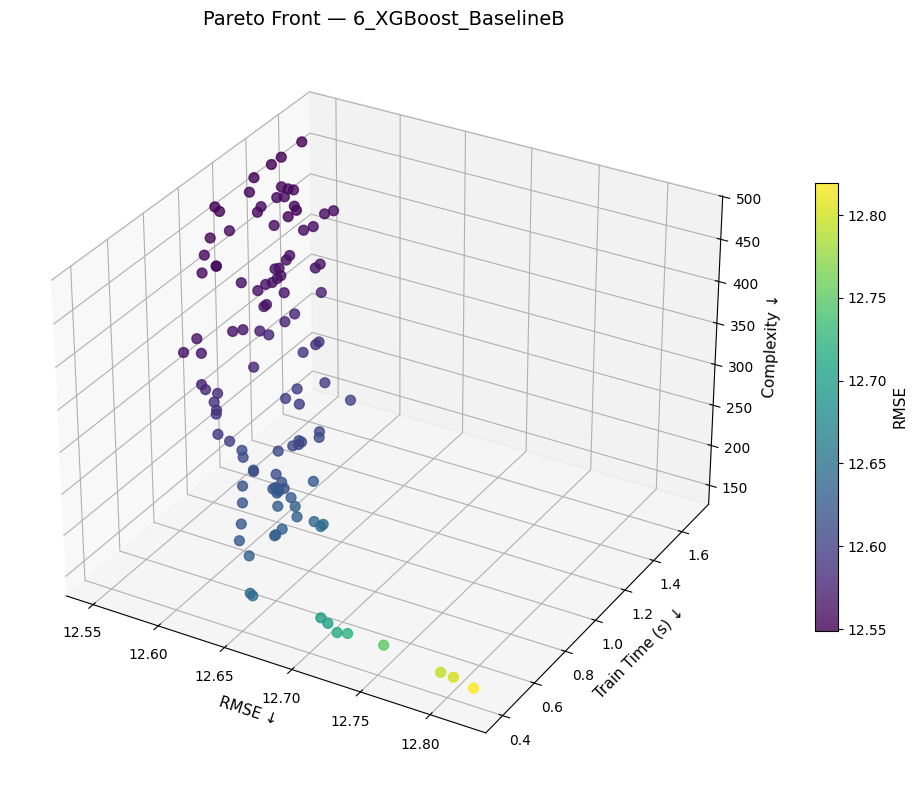

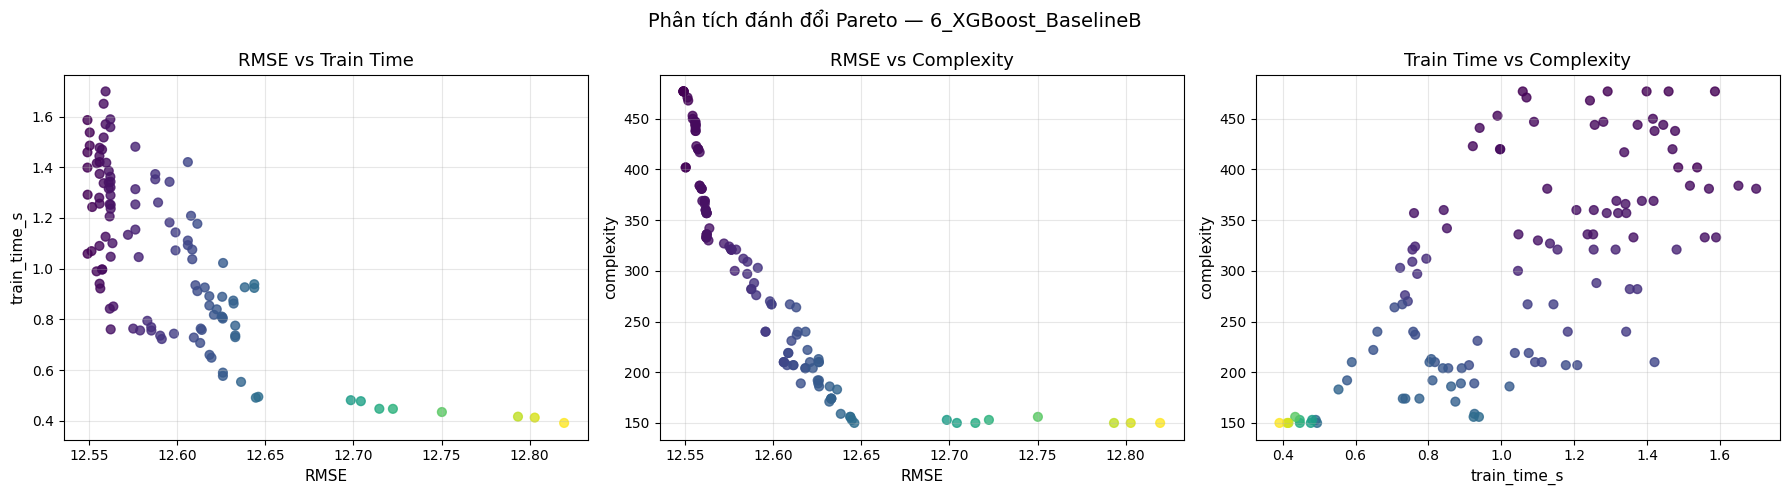

In [36]:
for model_name in best_model_names:
    print(f'\n--- Pareto Front: {model_name} ---')
    
    # Baseline A
    print('\n📊 Baseline A:')
    pareto_a = pareto_results_a[model_name]['pareto_df']
    optim.plot_pareto_front_3d(pareto_a, f'{model_name}_BaselineA',
                               save_dir=CONFIG['images_dir'])
    optim.plot_pareto_2d_pairs(pareto_a, f'{model_name}_BaselineA',
                               save_dir=CONFIG['images_dir'])
    
    # Baseline B
    print('\n📊 Baseline B:')
    pareto_b = pareto_results_b[model_name]['pareto_df']
    optim.plot_pareto_front_3d(pareto_b, f'{model_name}_BaselineB',
                               save_dir=CONFIG['images_dir'])
    optim.plot_pareto_2d_pairs(pareto_b, f'{model_name}_BaselineB',
                               save_dir=CONFIG['images_dir'])

### 7.6. Phân tích đánh đổi (Trade-off Analysis)

Code chọn 4 loại nghiệm trên Pareto front như sau:

- **Nghiệm tốt nhất theo RMSE**: dòng có `RMSE` nhỏ nhất (`idxmin`).
- **Nghiệm nhanh nhất**: dòng có `train_time_s` nhỏ nhất.
- **Nghiệm đơn giản nhất**: dòng có `complexity` nhỏ nhất.
- **Nghiệm cân bằng**: chuẩn hóa min-max ba mục tiêu `RMSE`, `train_time_s`, `complexity` về khoảng `[0, 1]`, sau đó chọn nghiệm có khoảng cách Euclid nhỏ nhất tới điểm lý tưởng `(0, 0, 0)`.


In [37]:
optimized_solutions = {'Baseline_A': {}, 'Baseline_B': {}}
optimized_params = {'Baseline_A': {}, 'Baseline_B': {}}

for model_name in best_model_names:
    print(f'\n{"="*60}')
    print(f'📊 PHÂN TÍCH ĐÁNH ĐỔI — {model_name}')

    print('\n--- Baseline A ---')
    pareto_a = pareto_results_a[model_name]['pareto_df']
    conclusion_a, best_a = optim.analyze_tradeoffs(pareto_a, f'{model_name} (Baseline A)')
    optimized_solutions['Baseline_A'][model_name] = best_a
    optimized_params['Baseline_A'][model_name] = stability.params_from_solution(model_name, best_a)

    print('\n--- Baseline B ---')
    pareto_b = pareto_results_b[model_name]['pareto_df']
    conclusion_b, best_b = optim.analyze_tradeoffs(pareto_b, f'{model_name} (Baseline B)')
    optimized_solutions['Baseline_B'][model_name] = best_b
    optimized_params['Baseline_B'][model_name] = stability.params_from_solution(model_name, best_b)

    print(f'\n🎯 Nghiệm cân bằng được đề xuất:')
    print(f'   Baseline A params: {optimized_params["Baseline_A"][model_name]}')
    print(f'   Baseline B params: {optimized_params["Baseline_B"][model_name]}')



📊 PHÂN TÍCH ĐÁNH ĐỔI — 5_RandomForest

--- Baseline A ---

📊 PHÂN TÍCH ĐÁNH ĐỔI — 5_RandomForest (Baseline A)
   Số nghiệm Pareto: 90

🧮 Cách code chọn nghiệm:
   - Nghiệm tốt nhất theo RMSE: idxmin('RMSE').
   - Nghiệm nhanh nhất: idxmin('train_time_s').
   - Nghiệm đơn giản nhất: idxmin('complexity').
   - Nghiệm cân bằng: min-max normalize RMSE, train_time_s, complexity rồi chọn khoảng cách Euclid nhỏ nhất tới (0,0,0).

🎯 Nghiệm tốt nhất theo RMSE:
   RMSE=13.1261, Time=36.546s, Complexity=1560, n_gen=64
   Params: {n_estimators=130, max_depth=12, min_samples_split=20, min_samples_leaf=1}

⚡ Nghiệm nhanh nhất:
   RMSE=14.9723, Time=5.466s, Complexity=150, n_gen=63
   Params: {n_estimators=50, max_depth=3, min_samples_split=16, min_samples_leaf=7}

🧩 Nghiệm đơn giản nhất:
   RMSE=14.9723, Time=5.466s, Complexity=150, n_gen=63
   Params: {n_estimators=50, max_depth=3, min_samples_split=16, min_samples_leaf=7}

📈 Phạm vi đánh đổi:
   RMSE: 13.1261 → 14.9723 (range=1.8462)
   Time: 5.4

---
## 8. Chứng minh độ ổn định bằng mô phỏng Monte Carlo

Sau khi Pymoo chọn nghiệm cân bằng cho từng mô hình, chạy Monte Carlo cho **4 trường hợp tối ưu**: 2 mô hình tốt nhất × 2 baseline. Vì đây là bài toán chuỗi thời gian, split train/valid/test phải giữ cố định theo thời gian; Monte Carlo chỉ thay đổi `random_state` của thuật toán để đo độ nhạy do tính ngẫu nhiên khi huấn luyện.


### 8.1. Cấu hình Monte Carlo


In [38]:
from configs.configs import STABILITY_CONFIG

mc_runs = STABILITY_CONFIG['monte_carlo_runs']
mc_seed_start = STABILITY_CONFIG['monte_carlo_seed_start']
mc_seeds = list(range(mc_seed_start, mc_seed_start + mc_runs))

print(f'✅ STABILITY_CONFIG: {STABILITY_CONFIG}')
print(f'Monte Carlo seeds: {mc_seeds[0]} → {mc_seeds[-1]} ({len(mc_seeds)} runs)')


✅ STABILITY_CONFIG: {'monte_carlo_runs': 100, 'monte_carlo_seed_start': 1000, 'sliding_train_ratio': 0.6, 'sliding_test_ratio': 0.1, 'sliding_step_ratio': 0.05, 'sliding_n_folds': 5, 'sliding_random_state': 69, 'stable_cv_threshold': 10.0}
Monte Carlo seeds: 1000 → 1099 (100 runs)


### 8.2. Chạy Monte Carlo cho 4 mô hình tối ưu


In [39]:
monte_carlo_inputs = {
    'Baseline_A': {
        'X_train': X_train_a,
        'y_train': y_train_a,
        'X_valid': X_valid_a,
        'y_valid': y_valid_a,
        'X_test': X_test_a,
        'y_test': y_test_a,
    },
    'Baseline_B': {
        'X_train': X_train_b,
        'y_train': y_train_b,
        'X_valid': X_valid_b,
        'y_valid': y_valid_b,
        'X_test': X_test_b,
        'y_test': y_test_b,
    },
}

mc_result_parts = []

for baseline_name, data in monte_carlo_inputs.items():
    for model_name in best_model_names:
        params = optimized_params[baseline_name][model_name]
        mc_df = stability.run_monte_carlo(
            model_name=model_name,
            params=params,
            X_train=data['X_train'],
            y_train=data['y_train'],
            X_valid=data['X_valid'],
            y_valid=data['y_valid'],
            X_test=data['X_test'],
            y_test=data['y_test'],
            baseline_name=baseline_name,
            seeds=mc_seeds,
        )
        mc_result_parts.append(mc_df)

monte_carlo_results = pd.concat(mc_result_parts, ignore_index=True)
monte_carlo_results



🎲 MONTE CARLO — Baseline_A — 5_RandomForest
   Runs: 100 | Split thời gian: giữ nguyên | Chỉ đổi random_state
   Run 01/100 | seed=1000 | RMSE=13.1574 | MAE=10.4523
   Run 02/100 | seed=1001 | RMSE=13.1509 | MAE=10.4460
   Run 03/100 | seed=1002 | RMSE=13.1468 | MAE=10.4417
   Run 04/100 | seed=1003 | RMSE=13.1793 | MAE=10.4718
   Run 05/100 | seed=1004 | RMSE=13.1786 | MAE=10.4595
   Run 06/100 | seed=1005 | RMSE=13.1579 | MAE=10.4492
   Run 07/100 | seed=1006 | RMSE=13.2055 | MAE=10.4785
   Run 08/100 | seed=1007 | RMSE=13.1826 | MAE=10.4713
   Run 09/100 | seed=1008 | RMSE=13.1749 | MAE=10.4529
   Run 10/100 | seed=1009 | RMSE=13.1694 | MAE=10.4652
   Run 11/100 | seed=1010 | RMSE=13.1937 | MAE=10.4810
   Run 12/100 | seed=1011 | RMSE=13.1735 | MAE=10.4635
   Run 13/100 | seed=1012 | RMSE=13.1854 | MAE=10.4721
   Run 14/100 | seed=1013 | RMSE=13.1796 | MAE=10.4719
   Run 15/100 | seed=1014 | RMSE=13.2012 | MAE=10.4802
   Run 16/100 | seed=1015 | RMSE=13.1537 | MAE=10.4431
   Run 17

,baseline,model,run,random_state,train_time_s,MAE,RMSE,MAPE,R2,MASE
0,Baseline_A,5_RandomForest,1,1000,1.2449,10.4523,13.1574,15.6525,0.8859,0.7645
1,Baseline_A,5_RandomForest,2,1001,1.1709,10.4460,13.1509,15.6179,0.8861,0.7640
2,Baseline_A,5_RandomForest,3,1002,1.2257,10.4417,13.1468,15.6382,0.8861,0.7637
3,Baseline_A,5_RandomForest,4,1003,1.2647,10.4718,13.1793,15.6694,0.8856,0.7659
4,Baseline_A,5_RandomForest,5,1004,1.1042,10.4595,13.1786,15.6741,0.8856,0.7650
...,...,...,...,...,...,...,...,...,...,...
395,Baseline_B,6_XGBoost,96,1095,0.0805,10.4146,13.1438,17.5425,0.8726,0.7687
396,Baseline_B,6_XGBoost,97,1096,0.0845,10.4398,13.1405,17.5707,0.8726,0.7705
397,Baseline_B,6_XGBoost,98,1097,0.0875,10.4554,13.1779,17.5768,0.8719,0.7717
398,Baseline_B,6_XGBoost,99,1098,0.0853,10.4304,13.1199,17.5578,0.8730,0.7698


### 8.3. Trực quan hóa kết quả Monte Carlo


,baseline,model,n_runs,RMSE_mean,RMSE_std,RMSE_min,RMSE_max,RMSE_ci95_low,RMSE_ci95_high,RMSE_cv_%
0,Baseline_A,6_XGBoost,100,12.9443,0.0319,12.8696,13.0203,12.9380,12.9505,0.2464
1,Baseline_B,6_XGBoost,100,13.1694,0.0289,13.1014,13.2419,13.1638,13.1751,0.2196
2,Baseline_A,5_RandomForest,100,13.1696,0.0148,13.1368,13.2055,13.1667,13.1725,0.1121
3,Baseline_B,5_RandomForest,100,13.3803,0.0145,13.3479,13.4111,13.3775,13.3832,0.1084


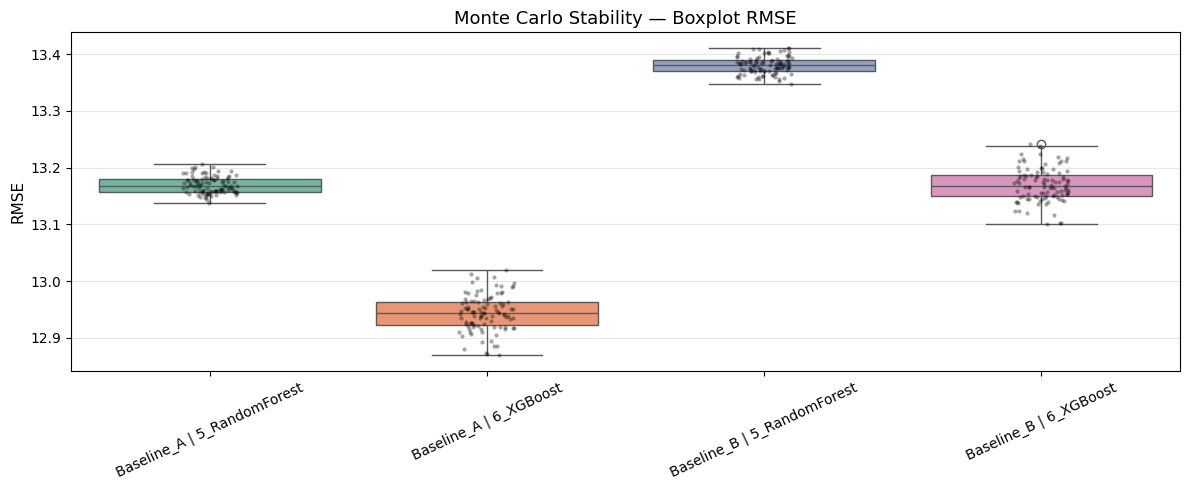

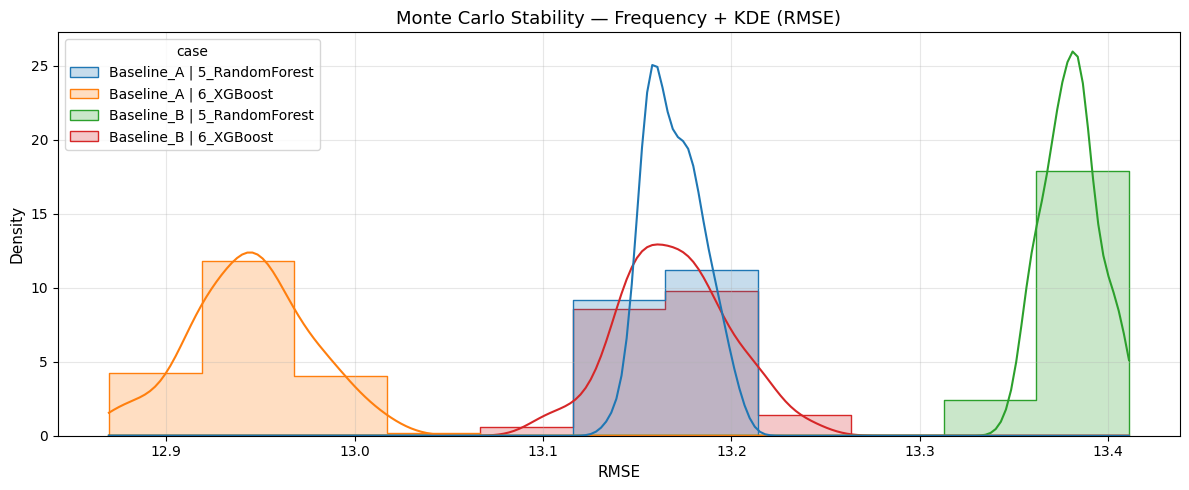

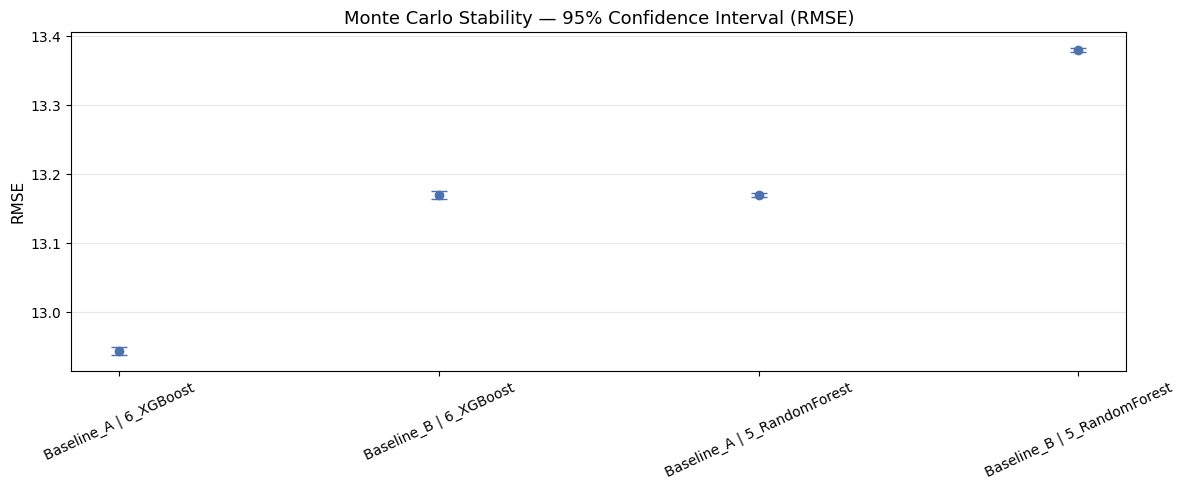

In [40]:
mc_summary = stability.summarize_monte_carlo(monte_carlo_results, metric='RMSE')
display(mc_summary)

stability.plot_monte_carlo_boxplot(
    monte_carlo_results,
    metric='RMSE',
    save_path=f"{CONFIG['images_dir']}/monte_carlo_rmse_boxplot.png",
)
stability.plot_monte_carlo_kde(
    monte_carlo_results,
    metric='RMSE',
    save_path=f"{CONFIG['images_dir']}/monte_carlo_rmse_kde.png",
)
stability.plot_monte_carlo_ci(
    mc_summary,
    metric='RMSE',
    save_path=f"{CONFIG['images_dir']}/monte_carlo_rmse_ci95.png",
)


---
## 9. Chứng minh độ ổn định của bộ dữ liệu bằng kỹ thuật trượt thời gian

Dùng 5 cửa sổ trượt theo đúng hướng dẫn: train 60%, test 10%, bước trượt 5%. Ở mỗi fold, tập train luôn nằm trước tập test theo thời gian, không có trộn ngẫu nhiên. Nếu RMSE trên các fold dao động nhỏ, bộ dữ liệu không có biến động bất thường lớn giữa các giai đoạn thời gian.


### 9.1. Chạy 5 cửa sổ trượt thời gian


In [41]:
sliding_inputs = {
    'Baseline_A': df_baseline_a,
    'Baseline_B': df_baseline_b,
}

sliding_result_parts = []

for baseline_name, baseline_df in sliding_inputs.items():
    for model_name in best_model_names:
        params = optimized_params[baseline_name][model_name]
        fold_df = stability.run_time_sliding_validation(
            df=baseline_df,
            feature_cols=FEATURE_COLS,
            target_col=TARGET_COL,
            model_name=model_name,
            params=params,
            baseline_name=baseline_name,
            random_state=STABILITY_CONFIG['sliding_random_state'],
            train_ratio=STABILITY_CONFIG['sliding_train_ratio'],
            test_ratio=STABILITY_CONFIG['sliding_test_ratio'],
            step_ratio=STABILITY_CONFIG['sliding_step_ratio'],
            n_folds=STABILITY_CONFIG['sliding_n_folds'],
        )
        sliding_result_parts.append(fold_df)

time_sliding_results = pd.concat(sliding_result_parts, ignore_index=True)
time_sliding_results



🪟 TIME SLIDING — Baseline_A — 5_RandomForest
   Train 60% | Test 10% | Step 5% | Folds 5
   Fold 1 | Train 0-60% | Test 60-70% | RMSE=13.3612
   Fold 2 | Train 5-65% | Test 65-75% | RMSE=13.6224
   Fold 3 | Train 10-70% | Test 70-80% | RMSE=13.4880
   Fold 4 | Train 15-75% | Test 75-85% | RMSE=13.1456
   Fold 5 | Train 20-80% | Test 80-90% | RMSE=13.1116

🪟 TIME SLIDING — Baseline_A — 6_XGBoost
   Train 60% | Test 10% | Step 5% | Folds 5
   Fold 1 | Train 0-60% | Test 60-70% | RMSE=13.1103
   Fold 2 | Train 5-65% | Test 65-75% | RMSE=13.2981
   Fold 3 | Train 10-70% | Test 70-80% | RMSE=13.1735
   Fold 4 | Train 15-75% | Test 75-85% | RMSE=12.6087
   Fold 5 | Train 20-80% | Test 80-90% | RMSE=12.6146

🪟 TIME SLIDING — Baseline_B — 5_RandomForest
   Train 60% | Test 10% | Step 5% | Folds 5
   Fold 1 | Train 0-60% | Test 60-70% | RMSE=13.1516
   Fold 2 | Train 5-65% | Test 65-75% | RMSE=13.0860
   Fold 3 | Train 10-70% | Test 70-80% | RMSE=13.3553
   Fold 4 | Train 15-75% | Test 75-85% 

,baseline,model,fold,train_pct,test_pct,n_train,n_test,train_time_s,MAE,RMSE,MAPE,R2,MASE
0,Baseline_A,5_RandomForest,1,0-60%,60-70%,14480,2412,0.8793,10.5867,13.3612,15.0452,0.8846,0.7758
1,Baseline_A,5_RandomForest,2,5-65%,65-75%,14476,2416,0.8224,10.8936,13.6224,15.4787,0.8874,0.7939
2,Baseline_A,5_RandomForest,3,10-70%,70-80%,14480,2412,0.8043,10.7957,13.4880,17.9379,0.8753,0.7852
3,Baseline_A,5_RandomForest,4,15-75%,75-85%,14480,2412,0.8161,10.4681,13.1456,20.3418,0.8380,0.7616
4,Baseline_A,5_RandomForest,5,20-80%,80-90%,14476,2416,0.8380,10.4180,13.1116,18.4015,0.8699,0.7587
5,Baseline_A,6_XGBoost,1,0-60%,60-70%,14480,2412,0.0900,10.4184,13.1103,14.8207,0.8888,0.7634
6,Baseline_A,6_XGBoost,2,5-65%,65-75%,14476,2416,0.0840,10.7117,13.2981,15.2030,0.8927,0.7807
7,Baseline_A,6_XGBoost,3,10-70%,70-80%,14480,2412,0.0756,10.5539,13.1735,17.4337,0.8810,0.7676
8,Baseline_A,6_XGBoost,4,15-75%,75-85%,14480,2412,0.0814,9.9851,12.6087,19.2774,0.8509,0.7265
9,Baseline_A,6_XGBoost,5,20-80%,80-90%,14476,2416,0.0845,10.0383,12.6146,17.5829,0.8796,0.7311


### 9.2. Tổng hợp và trực quan hóa độ ổn định theo thời gian


,baseline,model,n_folds,RMSE_mean,RMSE_std,RMSE_min,RMSE_max,RMSE_range,RMSE_cv_%,stable_by_cv
0,Baseline_B,6_XGBoost,5,12.8111,0.0849,12.7433,12.9567,0.2134,0.6624,True
1,Baseline_B,5_RandomForest,5,13.2321,0.1120,13.0860,13.3553,0.2693,0.8465,True
2,Baseline_A,5_RandomForest,5,13.3458,0.2190,13.1116,13.6224,0.5108,1.6412,True
3,Baseline_A,6_XGBoost,5,12.9610,0.3260,12.6087,13.2981,0.6894,2.5155,True


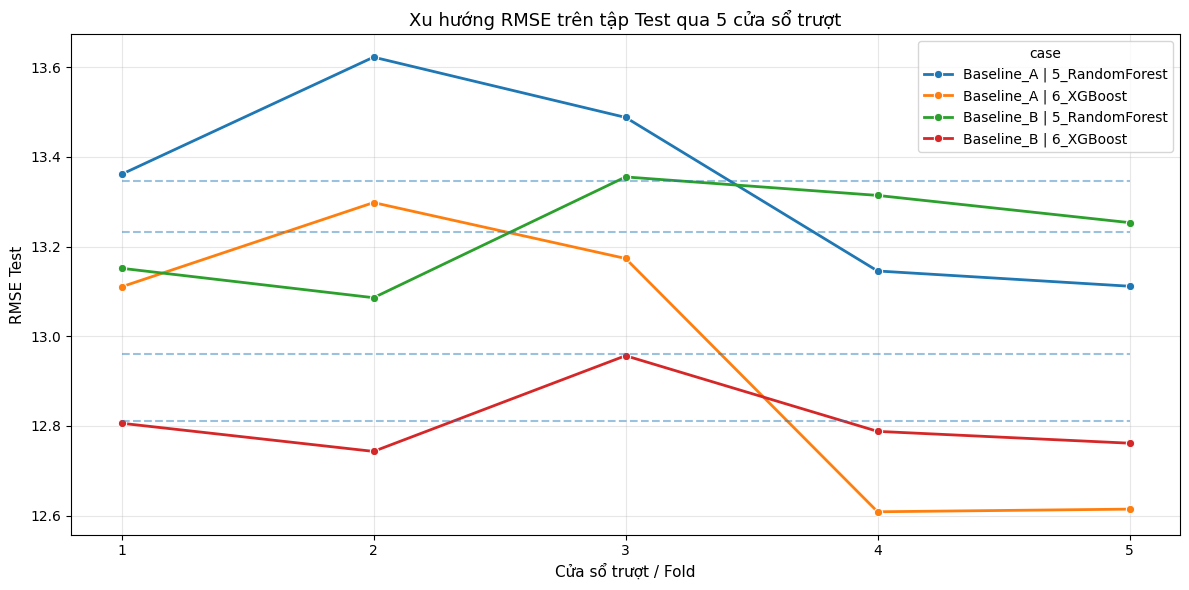

In [42]:
sliding_summary = stability.summarize_time_sliding(
    time_sliding_results,
    metric='RMSE',
    stable_cv_threshold=STABILITY_CONFIG['stable_cv_threshold'],
)
display(sliding_summary)

stability.plot_time_sliding_rmse(
    time_sliding_results,
    save_path=f"{CONFIG['images_dir']}/time_sliding_rmse.png",
)


### 9.3. Kết luận kiểm định ổn định

Diễn giải bảng `sliding_summary`: nếu `RMSE_cv_%` nhỏ hơn ngưỡng cấu hình (`stable_cv_threshold`, mặc định 10%) và đường RMSE qua 5 fold gần như nằm ngang, có thể kết luận dữ liệu ổn định theo thời gian đối với bài toán dự báo flow. Nếu một fold tăng RMSE đột biến, cần kiểm tra giai đoạn thời gian tương ứng vì có thể xuất hiện biến động giao thông bất thường hoặc lỗi cảm biến.


### 9.4. So sánh cuối để chọn mô hình tốt nhất sau Pymoo và stability

Nghiệm Pymoo chỉ chứng minh một bộ siêu tham số tốt trên validation theo 3 mục tiêu `RMSE`, `train_time_s`, `complexity`. Để kết luận đây có phải mô hình tốt nhất và ổn định nhất không, cần ghép thêm kết quả test cố định qua Monte Carlo và kết quả trượt thời gian. Bảng dưới đây chuẩn hóa các tiêu chí theo hướng càng thấp càng tốt và tính `final_score`: score thấp nhất là mô hình được chọn cuối cùng.


In [43]:
final_selection_metrics = stability.get_final_selection_metrics()
display(final_selection_metrics)

final_scorecard = stability.build_final_model_scorecard(
    results_a=results_a,
    results_b=results_b,
    optimized_solutions=optimized_solutions,
    optimized_params=optimized_params,
    monte_carlo_results=monte_carlo_results,
    time_sliding_results=time_sliding_results,
    stable_cv_threshold=STABILITY_CONFIG['stable_cv_threshold'],
)

scorecard_cols = [
    'rank', 'case', 'final_score',
    'mc_RMSE_mean', 'mc_RMSE_std', 'mc_RMSE_cv_%',
    'sliding_RMSE_mean', 'sliding_RMSE_std', 'sliding_RMSE_cv_%',
    'pareto_valid_RMSE', 'pareto_train_time_s', 'pareto_complexity',
    'stable_overall', 'optimized_params',
]
scorecard_cols = [col for col in scorecard_cols if col in final_scorecard.columns]
display(final_scorecard[scorecard_cols])

best_final_model = stability.print_final_model_conclusion(final_scorecard)
best_final_model


,metric,group,direction,weight,meaning
0,mc_RMSE_mean,Hiệu năng test sau Pymoo,min,0.300,RMSE trung bình trên test cố định qua các seed...
1,sliding_RMSE_mean,Hiệu năng theo thời gian,min,0.250,RMSE trung bình qua 5 cửa sổ trượt thời gian.
2,pareto_valid_RMSE,Nghiệm Pymoo,min,0.100,RMSE validation của nghiệm cân bằng trên Paret...
3,mc_RMSE_cv_%,Ổn định thuật toán,min,0.150,Hệ số biến thiên RMSE khi chỉ đổi random_state.
4,sliding_RMSE_cv_%,Ổn định dữ liệu,min,0.150,Hệ số biến thiên RMSE qua các fold trượt thời ...
5,pareto_train_time_s,Chi phí,min,0.025,Thời gian huấn luyện của nghiệm cân bằng trong...
6,pareto_complexity,Chi phí,min,0.025,"Độ phức tạp mô hình, ví dụ n_estimators x max_..."


,rank,case,final_score,mc_RMSE_mean,mc_RMSE_std,mc_RMSE_cv_%,sliding_RMSE_mean,sliding_RMSE_std,sliding_RMSE_cv_%,pareto_valid_RMSE,pareto_train_time_s,pareto_complexity,stable_overall,optimized_params
0,1,Baseline_B | 6_XGBoost,0.2759,13.1694,0.0289,0.2196,12.8111,0.0849,0.6624,12.6259,0.5768,192.0,True,"{n_estimators=64, max_depth=3, learning_rate=0..."
1,2,Baseline_A | 6_XGBoost,0.3913,12.9443,0.0319,0.2464,12.9610,0.3260,2.5155,12.7776,0.5202,192.0,True,"{n_estimators=64, max_depth=3, learning_rate=0..."
2,3,Baseline_A | 5_RandomForest,0.6345,13.1696,0.0148,0.1121,13.3458,0.2190,1.6412,13.3405,10.5447,350.0,True,"{n_estimators=50, max_depth=7, min_samples_spl..."
3,4,Baseline_B | 5_RandomForest,0.6419,13.3803,0.0145,0.1084,13.2321,0.1120,0.8465,13.1984,12.3485,350.0,True,"{n_estimators=50, max_depth=7, min_samples_spl..."



KẾT LUẬN CHỌN MÔ HÌNH SAU PYMOO + STABILITY
Best overall: Baseline_B | 6_XGBoost | final_score=0.2759 | MC_RMSE=13.1694 | Sliding_RMSE=12.8111 | MC_CV=0.2196% | Sliding_CV=0.6624%
Params: {n_estimators=64, max_depth=3, learning_rate=0.260832, subsample=0.960676, colsample_bytree=0.711963, reg_alpha=5.62635, reg_lambda=7.42661}
Best MC RMSE: Baseline_A | 6_XGBoost (12.9443)
Best time-sliding RMSE: Baseline_B | 6_XGBoost (12.8111)
Ổn định nhất theo Monte Carlo CV: Baseline_B | 5_RandomForest (0.1084%)
Ổn định nhất theo time-sliding CV: Baseline_B | 6_XGBoost (0.6624%)
Kết luận: mô hình được chọn vừa có sai số thấp vừa đạt ngưỡng ổn định CV.


rank                                                                         1
baseline                                                            Baseline_B
model                                                                6_XGBoost
case                                                    Baseline_B | 6_XGBoost
optimized_params             {n_estimators=64, max_depth=3, learning_rate=0...
holdout_test_MAE                                                        10.618
holdout_test_RMSE                                                      13.3665
holdout_test_MAPE                                                      17.8084
holdout_test_R2                                                         0.8682
holdout_test_MASE                                                       0.7806
pareto_valid_RMSE                                                      12.6259
pareto_train_time_s                                                     0.5768
pareto_complexity                                   

Diễn giải tiêu chí trong code:

- `mc_RMSE_mean`: sai số test trung bình sau khi fit lại mô hình tối ưu trên train+valid và chỉ đổi `random_state`. Đây là tiêu chí hiệu năng chính sau Pymoo.
- `mc_RMSE_cv_%`: độ dao động do yếu tố ngẫu nhiên của thuật toán; càng thấp mô hình càng ổn định.
- `sliding_RMSE_mean`: sai số trung bình qua các giai đoạn thời gian khác nhau; dùng để kiểm tra mô hình có tổng quát theo thời gian không.
- `sliding_RMSE_cv_%`: độ ổn định của bộ dữ liệu/mô hình qua 5 cửa sổ trượt; nhỏ hơn `stable_cv_threshold` thì đạt ổn định.
- `pareto_valid_RMSE`, `pareto_train_time_s`, `pareto_complexity`: 3 mục tiêu Pymoo của nghiệm cân bằng, dùng làm tiêu chí phụ để tránh chọn nghiệm chỉ tốt trên test nhưng quá nặng hoặc không nhất quán với validation.

Vì vậy, một mô hình chỉ được xem là tốt nhất khi có RMSE thấp, CV thấp, đạt ổn định qua trượt thời gian và không có chi phí/độ phức tạp bất thường.


---
## 10. Giải Thích & Độ Nhạy (XAI) cho 4 mô hình tối ưu

Sau Pymoo, Monte Carlo và trượt thời gian, phần này chỉ dùng **SHAP** cho 4 case tối ưu hiện tại: Baseline A/B × `6_XGBoost`/`5_RandomForest`. Pipeline này chỉ dùng SHAP. Mỗi hình SHAP summary chỉ hiển thị 14 feature ảnh hưởng mạnh nhất; toàn bộ feature còn lại được gộp vào dòng `other`.


### 10.1. Cấu hình và chạy SHAP top 14 + other

SHAP — mô hình tối ưu gốc — Baseline_A | 5_RandomForest


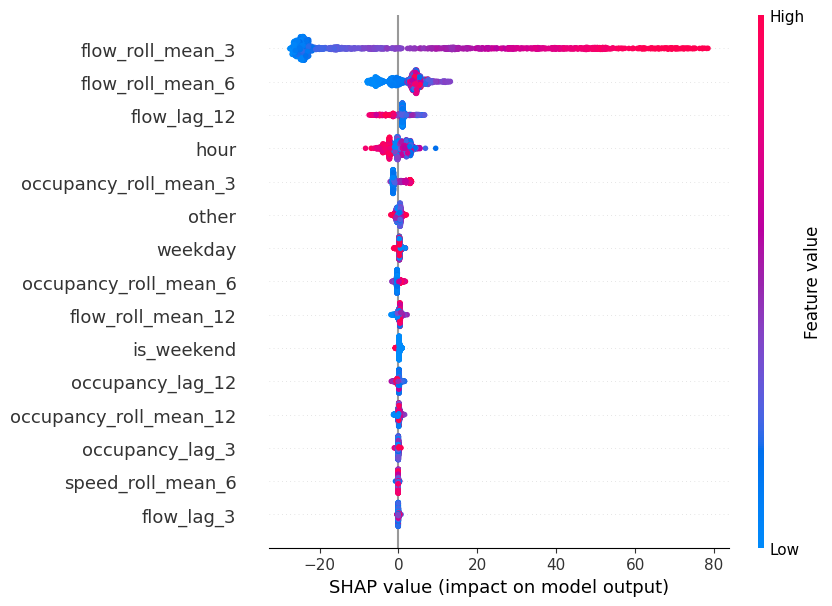

SHAP — mô hình tối ưu gốc — Baseline_A | 6_XGBoost


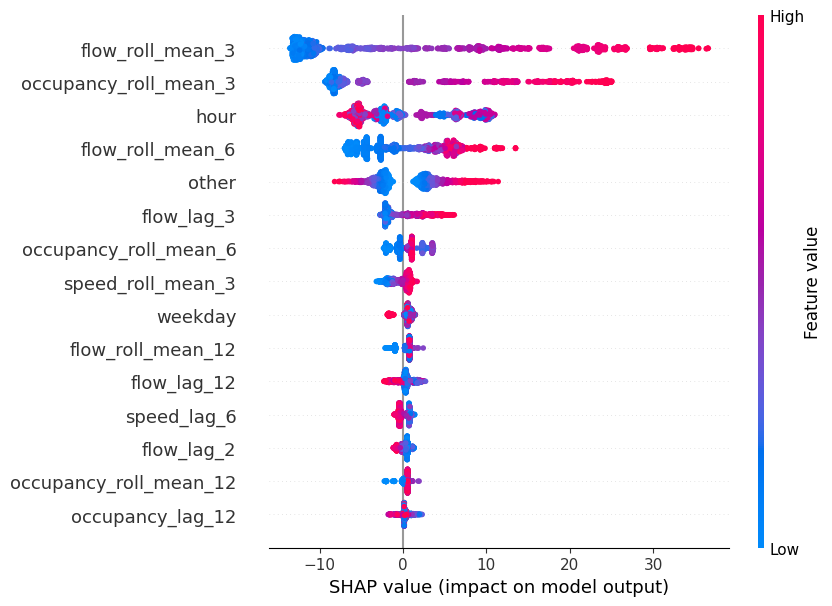

SHAP — mô hình tối ưu gốc — Baseline_B | 5_RandomForest


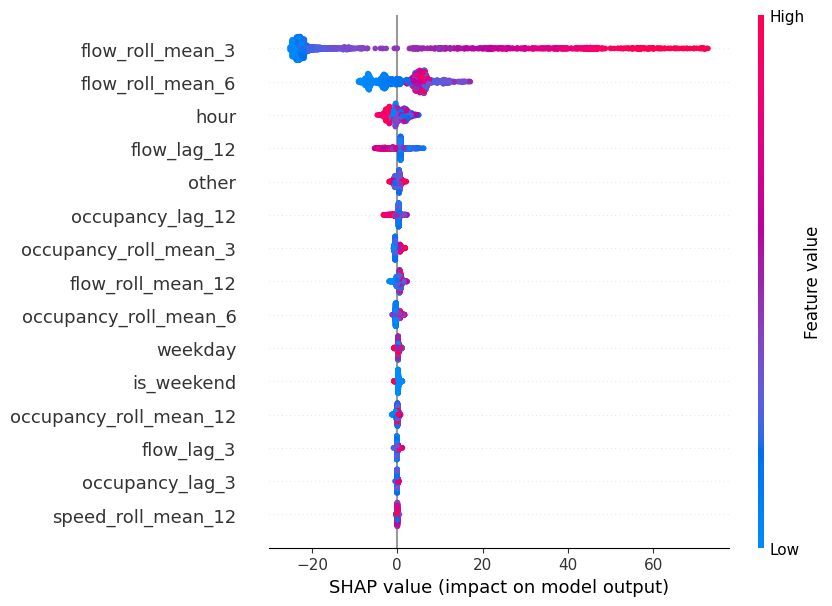

SHAP — mô hình tối ưu gốc — Baseline_B | 6_XGBoost


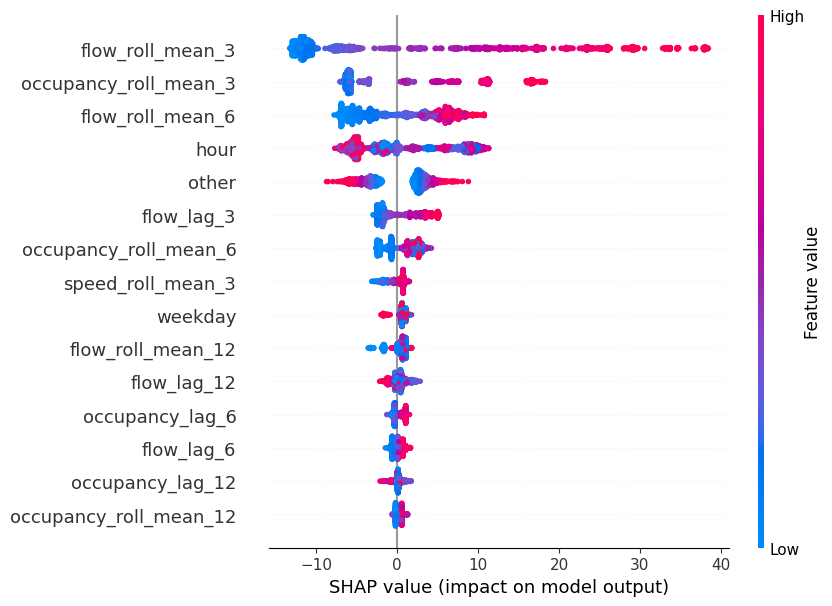

,stage,baseline,model,case,feature,mean_abs_shap,is_other,rank
0,optimized_original,Baseline_A,5_RandomForest,Baseline_A | 5_RandomForest,flow_roll_mean_3,27.829809,False,1
1,optimized_original,Baseline_A,5_RandomForest,Baseline_A | 5_RandomForest,flow_roll_mean_6,4.199434,False,2
2,optimized_original,Baseline_A,5_RandomForest,Baseline_A | 5_RandomForest,flow_lag_12,2.071449,False,3
3,optimized_original,Baseline_A,5_RandomForest,Baseline_A | 5_RandomForest,hour,1.867680,False,4
4,optimized_original,Baseline_A,5_RandomForest,Baseline_A | 5_RandomForest,occupancy_roll_mean_3,1.596044,False,5
5,optimized_original,Baseline_A,5_RandomForest,Baseline_A | 5_RandomForest,other,0.515876,True,6
6,optimized_original,Baseline_A,5_RandomForest,Baseline_A | 5_RandomForest,weekday,0.436560,False,7
7,optimized_original,Baseline_A,5_RandomForest,Baseline_A | 5_RandomForest,occupancy_roll_mean_6,0.400074,False,8
8,optimized_original,Baseline_A,5_RandomForest,Baseline_A | 5_RandomForest,flow_roll_mean_12,0.368705,False,9
9,optimized_original,Baseline_A,5_RandomForest,Baseline_A | 5_RandomForest,is_weekend,0.307123,False,10


In [44]:
from configs.configs import XAI_CONFIG

xai_inputs = {
    'Baseline_A': {'train': train_a, 'valid': valid_a, 'test': test_a},
    'Baseline_B': {'train': train_b, 'valid': valid_b, 'test': test_b},
}

optimized_shap_results = {}
optimized_shap_tables = []

for case in optimized_cases:
    baseline_name = case['baseline']
    model_name = case['model']
    case_name = case['case']
    data = xai_inputs[baseline_name]
    params = optimized_params[baseline_name][model_name]

    print(f'{"="*70}')
    print(f'SHAP — mô hình tối ưu gốc — {case_name}')
    print(f'{"="*70}')

    fitted_model, explain_fit_df = explainability.fit_optimized_model(
        model_name=model_name,
        params=params,
        train_df=data['train'],
        valid_df=data['valid'],
        feature_cols=FEATURE_COLS,
        target_col=TARGET_COL,
        random_state=XAI_CONFIG['random_state'],
    )

    shap_result = explainability.compute_shap_values(
        model=fitted_model,
        data_df=data['test'],
        feature_cols=FEATURE_COLS,
        sample_size=XAI_CONFIG['shap_sample_size'],
        random_state=XAI_CONFIG['random_state'],
    )

    safe_prefix = f"{baseline_name}_{model_name}_optimized".replace('/', '_').replace(' ', '_')
    plot_result = explainability.plot_shap_summary(
        shap_result,
        save_dir=CONFIG['images_dir'],
        prefix=safe_prefix,
        max_display=XAI_CONFIG['top_features'] + 1,
        top_features=XAI_CONFIG['top_features'],
        other_label=XAI_CONFIG['other_label'],
    )

    shap_table = explainability.shap_top_other_table(
        shap_result,
        case=case_name,
        baseline=baseline_name,
        model=model_name,
        stage='optimized_original',
        top_features=XAI_CONFIG['top_features'],
        other_label=XAI_CONFIG['other_label'],
    )
    optimized_shap_tables.append(shap_table)
    optimized_shap_results[case_name] = {
        'model': fitted_model,
        'fit_df': explain_fit_df,
        'shap_result': shap_result,
        'plot_result': plot_result,
        'table': shap_table,
    }

optimized_shap_summary = pd.concat(optimized_shap_tables, ignore_index=True)
optimized_shap_summary.to_csv(
    f"{CONFIG['clean_dir']}/optimized_shap_top14_other.csv",
    index=False,
)
display(optimized_shap_summary)


Cách đọc bảng SHAP: `rank` được tính sau khi đã gộp các feature ngoài top 14 vào `other`. Nếu `other` có `mean_abs_shap` lớn, mô hình còn phụ thuộc đáng kể vào nhóm feature phụ; nếu `other` thấp, 14 feature đầu đã giải thích phần lớn độ nhạy của mô hình.


---
## 11. Tạo sinh dữ liệu bằng GAN

Theo `.docs/GAN.md`, phần GAN gồm sinh dữ liệu ảo, đánh giá chéo Real/Fake, gộp dữ liệu theo không gian mẫu, đào tạo mô hình tổng quát và so sánh XAI. Pipeline hiện dùng chiến lược **feature-space/sample-space**: dữ liệu chuỗi thời gian đã được chuyển thành supervised samples bằng lag/rolling/time features, sau đó GAN học `FEATURE_COLS + flow_target`. Vì vậy notebook không ghép timestamp giả vào chuỗi thời gian thật.


### 11.1. Cấu hình GAN và sinh dữ liệu ảo theo baseline

GAN được train theo từng baseline vì GAN học phân phối dữ liệu của cụm sensor. Sau đó cùng tập synthetic của baseline đó được dùng để đánh giá cả 2 mô hình tối ưu trong baseline.


In [45]:
from configs.configs import GAN_CONFIG
from modules import gan_synthetic

print(f'✅ GAN_CONFIG: {GAN_CONFIG}')

max_aug_ratio = max(GAN_CONFIG['augmentation_ratios'])
min_generation_ratio = max(max_aug_ratio, GAN_CONFIG['synthetic_ratio'])
gan_inputs = {
    'Baseline_A': {'train': train_a, 'test': test_a},
    'Baseline_B': {'train': train_b, 'test': test_b},
}

gan_artifacts_by_baseline = {}
synthetic_by_baseline = {}

for baseline_name, data in gan_inputs.items():
    train_df = data['train']
    sample_size = min(GAN_CONFIG['sample_size'], len(train_df))
    n_synthetic = int(round(len(train_df) * min_generation_ratio))

    print(f'{"="*70}')
    print(f'GAN — {baseline_name} | sample_size={sample_size:,} | n_synthetic={n_synthetic:,}')
    print(f'{"="*70}')

    gan_artifacts = gan_synthetic.train_feature_gan(
        df=train_df,
        feature_cols=FEATURE_COLS,
        target_col=TARGET_COL,
        sample_size=sample_size,
        noise_dim=GAN_CONFIG['noise_dim'],
        hidden_dim=GAN_CONFIG['hidden_dim'],
        epochs=GAN_CONFIG['epochs'],
        batch_size=GAN_CONFIG['batch_size'],
        lr=GAN_CONFIG['lr'],
        random_state=GAN_CONFIG['random_state'],
    )
    synthetic_df = gan_synthetic.generate_synthetic_data(
        gan_artifacts=gan_artifacts,
        n_samples=n_synthetic,
        reference_df=train_df,
        random_state=GAN_CONFIG['random_state'],
    )

    safe_ratio = str(min_generation_ratio).replace('.', 'p')
    output_path = f"{CONFIG['clean_dir']}/{baseline_name}_gan_synthetic_max{safe_ratio}.csv"
    gan_synthetic.save_synthetic_data(synthetic_df, output_path)

    gan_artifacts_by_baseline[baseline_name] = gan_artifacts
    synthetic_by_baseline[baseline_name] = synthetic_df

    display(gan_artifacts['history'].tail())
    display(synthetic_df.head())


✅ GAN_CONFIG: {'sample_size': 8000, 'synthetic_ratio': 1.0, 'augmentation_ratios': [0.0, 0.5, 1.0, 2.0], 'noise_dim': 32, 'hidden_dim': 128, 'epochs': 100, 'batch_size': 256, 'lr': 0.0002, 'random_state': 42}
GAN — Baseline_A | sample_size=8,000 | n_synthetic=33,784

HUẤN LUYỆN FEATURE-SPACE GAN
   Samples: 8,000 | Data dim: 37 | Device: cpu
   Epochs: 100 | Batch: 256 | Noise dim: 32
   Epoch 001/100 | D_loss=1.3443 | G_loss=0.6685
   Epoch 050/100 | D_loss=1.3678 | G_loss=0.8127
   Epoch 100/100 | D_loss=1.3586 | G_loss=0.8195
Đã lưu synthetic data: __datasets-clean\Baseline_A_gan_synthetic_max2p0.csv (33,784 dòng)


,epoch,d_loss,g_loss
95,96,1.359444,0.819659
96,97,1.359482,0.822578
97,98,1.360191,0.823917
98,99,1.356856,0.822304
99,100,1.358630,0.819465


,sensor_id,flow_lag_1,flow_lag_2,flow_lag_3,flow_lag_6,flow_lag_12,speed_lag_1,speed_lag_2,speed_lag_3,speed_lag_6,...,occupancy_roll_std_3,occupancy_roll_mean_6,occupancy_roll_std_6,occupancy_roll_mean_12,occupancy_roll_std_12,hour,weekday,is_weekend,flow_target,source
0,PEMSD3_010,48.967113,45.434399,83.879784,63.358383,46.679008,59.629745,56.245213,44.687851,55.598068,...,0.112006,0.312074,0.116260,0.343652,0.091450,2.0,1.0,0.0,39.954647,synthetic_gan
1,PEMSD3_007,35.732800,48.251667,42.340981,48.321995,57.892899,63.243893,56.637054,56.112114,59.530193,...,0.034042,0.268739,0.069889,0.237408,0.072737,17.0,5.0,1.0,52.771423,synthetic_gan
2,PEMSD3_008,115.301826,97.264061,107.676498,102.854927,62.931831,43.932892,44.884460,45.234211,39.820869,...,0.060178,0.609763,0.069166,0.597059,0.112480,8.0,1.0,0.0,113.189392,synthetic_gan
3,PEMSD3_009,95.286453,87.972061,72.952827,95.879860,72.700287,50.765858,48.886822,53.811916,50.575478,...,0.021916,0.540430,0.059928,0.478970,0.062757,8.0,5.0,1.0,91.000938,synthetic_gan
4,PEMSD3_009,50.425751,56.776192,48.679276,85.950584,83.478973,55.389614,51.724361,56.089172,49.854836,...,0.082060,0.328090,0.054856,0.352920,0.075775,23.0,4.0,0.0,41.440426,synthetic_gan


GAN — Baseline_B | sample_size=8,000 | n_synthetic=33,784

HUẤN LUYỆN FEATURE-SPACE GAN
   Samples: 8,000 | Data dim: 37 | Device: cpu
   Epochs: 100 | Batch: 256 | Noise dim: 32
   Epoch 001/100 | D_loss=1.3452 | G_loss=0.6680
   Epoch 050/100 | D_loss=1.3682 | G_loss=0.8113
   Epoch 100/100 | D_loss=1.3540 | G_loss=0.8243
Đã lưu synthetic data: __datasets-clean\Baseline_B_gan_synthetic_max2p0.csv (33,784 dòng)


,epoch,d_loss,g_loss
95,96,1.357524,0.825003
96,97,1.358564,0.827052
97,98,1.358360,0.825625
98,99,1.354834,0.823489
99,100,1.354002,0.824336


,sensor_id,flow_lag_1,flow_lag_2,flow_lag_3,flow_lag_6,flow_lag_12,speed_lag_1,speed_lag_2,speed_lag_3,speed_lag_6,...,occupancy_roll_std_3,occupancy_roll_mean_6,occupancy_roll_std_6,occupancy_roll_mean_12,occupancy_roll_std_12,hour,weekday,is_weekend,flow_target,source
0,PEMSD3_014,66.892693,45.603352,76.359962,73.780098,30.084137,53.678314,55.508915,54.102356,48.679829,...,0.086428,0.339616,0.118801,0.326364,0.108411,1.0,0.0,0.0,43.296661,synthetic_gan
1,PEMSD3_011,35.673229,53.447151,25.383530,35.441563,22.572289,63.113438,51.640770,53.829460,55.705803,...,0.068234,0.190868,0.068373,0.254199,0.082683,13.0,4.0,1.0,42.896168,synthetic_gan
2,PEMSD3_012,116.196388,93.964600,117.462662,112.756439,80.320503,43.384514,50.882786,47.683716,41.961670,...,0.032403,0.613319,0.080177,0.632314,0.104422,6.0,2.0,0.0,136.105408,synthetic_gan
3,PEMSD3_013,77.143784,72.368233,43.422543,57.603004,57.314178,50.247528,53.404572,51.026047,53.632637,...,0.061205,0.352807,0.054635,0.424123,0.076441,12.0,5.0,1.0,54.100365,synthetic_gan
4,PEMSD3_013,74.443596,63.426346,58.894493,82.804337,71.622627,52.595306,49.237988,58.757042,43.446880,...,0.082666,0.392557,0.071339,0.358796,0.070589,20.0,1.0,0.0,67.144753,synthetic_gan


### 11.2. Đánh giá chéo Real/Fake cho 4 case

Chạy hai kịch bản Train Real/Test Fake và Train Fake/Test Real cho các tỉ lệ có dữ liệu synthetic: `0.5`, `1.0`, `2.0`. Tỉ lệ `0.0` là mốc real-only nên không có fake data để cross-evaluate.


In [46]:
cross_eval_ratios = [ratio for ratio in GAN_CONFIG['augmentation_ratios'] if ratio > 0]
gan_cross_parts = []

for case_idx, case in enumerate(optimized_cases):
    baseline_name = case['baseline']
    model_name = case['model']
    case_name = case['case']
    real_train_df = gan_inputs[baseline_name]['train']
    synthetic_full_df = synthetic_by_baseline[baseline_name]
    params = optimized_params[baseline_name][model_name]

    for ratio in cross_eval_ratios:
        n_fake = int(round(len(real_train_df) * ratio))
        fake_df = synthetic_full_df.sample(
            n=n_fake,
            replace=n_fake > len(synthetic_full_df),
            random_state=GAN_CONFIG['random_state'] + case_idx * 1000 + int(ratio * 100),
        ).reset_index(drop=True)

        eval_df = gan_synthetic.real_fake_cross_evaluation(
            model_name=model_name,
            params=params,
            real_df=real_train_df,
            fake_df=fake_df,
            feature_cols=FEATURE_COLS,
            target_col=TARGET_COL,
            random_state=GAN_CONFIG['random_state'],
            baseline_name=baseline_name,
            synthetic_ratio=ratio,
        )
        eval_df.insert(0, 'case', case_name)
        gan_cross_parts.append(eval_df)

gan_cross_evaluation_all = pd.concat(gan_cross_parts, ignore_index=True)
gan_cross_evaluation_all.to_csv(
    f"{CONFIG['clean_dir']}/gan_cross_evaluation_all.csv",
    index=False,
)
print(f'Số dòng cross-eval: {len(gan_cross_evaluation_all)}')
display(gan_cross_evaluation_all)


Số dòng cross-eval: 24


,case,scenario,model,n_train,n_test,MAE,RMSE,MAPE,R2,MASE,baseline,synthetic_ratio
0,Baseline_A | 5_RandomForest,Train Real / Test Fake,5_RandomForest,16892,8446,13.6873,17.0370,22.2071,0.8273,0.9992,Baseline_A,0.5
1,Baseline_A | 5_RandomForest,Train Fake / Test Real,5_RandomForest,8446,16892,13.0117,16.3126,20.1285,0.8129,0.2838,Baseline_A,0.5
2,Baseline_A | 5_RandomForest,Train Real / Test Fake,5_RandomForest,16892,16892,13.5490,16.8697,22.3559,0.8284,0.9891,Baseline_A,1.0
3,Baseline_A | 5_RandomForest,Train Fake / Test Real,5_RandomForest,16892,16892,13.0144,16.3485,20.0874,0.8121,0.2852,Baseline_A,1.0
4,Baseline_A | 5_RandomForest,Train Real / Test Fake,5_RandomForest,16892,33784,13.6735,17.0150,22.4928,0.8266,0.9982,Baseline_A,2.0
5,Baseline_A | 5_RandomForest,Train Fake / Test Real,5_RandomForest,33784,16892,13.0876,16.4351,20.2293,0.8101,0.2863,Baseline_A,2.0
6,Baseline_A | 6_XGBoost,Train Real / Test Fake,6_XGBoost,16892,8446,14.7008,18.2998,24.1690,0.7975,1.0732,Baseline_A,0.5
7,Baseline_A | 6_XGBoost,Train Fake / Test Real,6_XGBoost,8446,16892,13.9881,17.5190,21.2329,0.7842,0.3054,Baseline_A,0.5
8,Baseline_A | 6_XGBoost,Train Real / Test Fake,6_XGBoost,16892,16892,14.6051,18.1877,23.7916,0.8029,1.0662,Baseline_A,1.0
9,Baseline_A | 6_XGBoost,Train Fake / Test Real,6_XGBoost,16892,16892,13.9204,17.4174,21.2360,0.7867,0.3027,Baseline_A,1.0


### 11.3. Đào tạo mô hình tổng quát và tìm điểm bão hòa

Chạy augmentation theo 4 tỉ lệ `0.0`, `0.5`, `1.0`, `2.0`. Tỉ lệ `0.0` là mốc chỉ dùng dữ liệu thật để so sánh xem synthetic có cải thiện RMSE trên real test hay không.


Số dòng augmentation: 16


,case,scenario,model,synthetic_ratio,n_real_train,n_synthetic_train,n_test,MAE,RMSE,MAPE,R2,MASE,baseline
0,Baseline_A | 5_RandomForest,100% Real + 0% Synthetic,5_RandomForest,0.0,16892,0,3620,10.5137,13.2282,15.7502,0.8847,0.7675,Baseline_A
1,Baseline_A | 5_RandomForest,100% Real + 50% Synthetic,5_RandomForest,0.5,16892,8446,3620,10.8992,13.6941,16.2251,0.8764,0.4421,Baseline_A
2,Baseline_A | 5_RandomForest,100% Real + 100% Synthetic,5_RandomForest,1.0,16892,16892,3620,11.1435,13.9715,16.5345,0.8714,0.3741,Baseline_A
3,Baseline_A | 5_RandomForest,100% Real + 200% Synthetic,5_RandomForest,2.0,16892,33784,3620,11.5124,14.4046,17.0563,0.8633,0.3263,Baseline_A
4,Baseline_A | 6_XGBoost,100% Real + 0% Synthetic,6_XGBoost,0.0,16892,0,3620,10.2835,12.9420,15.3627,0.8896,0.7507,Baseline_A
5,Baseline_A | 6_XGBoost,100% Real + 50% Synthetic,6_XGBoost,0.5,16892,8446,3620,10.8469,13.6541,16.0934,0.8772,0.4400,Baseline_A
6,Baseline_A | 6_XGBoost,100% Real + 100% Synthetic,6_XGBoost,1.0,16892,16892,3620,11.3043,14.1595,16.7485,0.8679,0.3795,Baseline_A
7,Baseline_A | 6_XGBoost,100% Real + 200% Synthetic,6_XGBoost,2.0,16892,33784,3620,11.7463,14.7934,17.3024,0.8558,0.3329,Baseline_A
8,Baseline_B | 5_RandomForest,100% Real + 0% Synthetic,5_RandomForest,0.0,16892,0,3620,10.6825,13.4218,17.9474,0.8671,0.7853,Baseline_B
9,Baseline_B | 5_RandomForest,100% Real + 50% Synthetic,5_RandomForest,0.5,16892,8446,3620,10.9351,13.7485,18.2115,0.8606,0.4683,Baseline_B


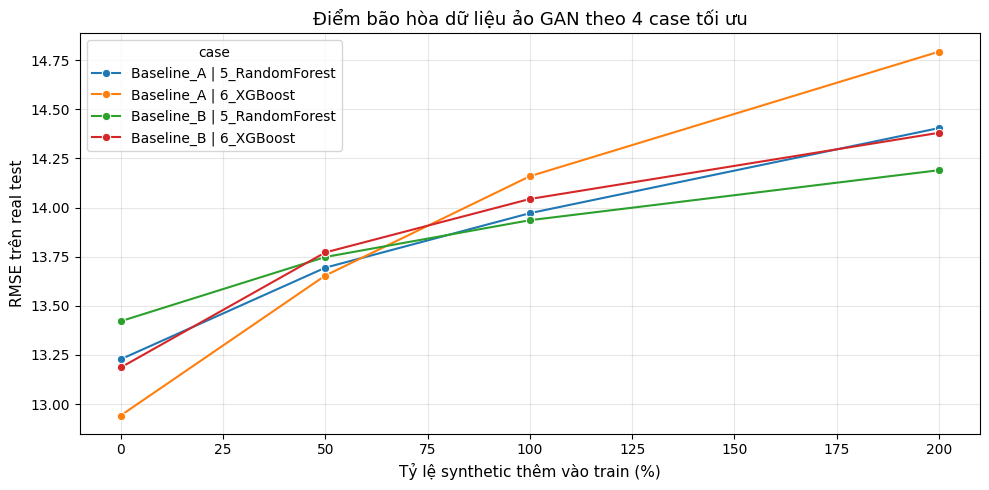

In [47]:
def build_augmented_training_frame(real_train_df, synthetic_df, ratio, random_state):
    n_fake = int(round(len(real_train_df) * ratio))
    if n_fake == 0:
        return real_train_df.copy()
    fake_part = synthetic_df.sample(
        n=n_fake,
        replace=n_fake > len(synthetic_df),
        random_state=random_state,
    )
    return pd.concat([real_train_df, fake_part], ignore_index=True)


gan_augmentation_parts = []
gan_best_rows = {}
gan_best_train_frames = {}

for case_idx, case in enumerate(optimized_cases):
    baseline_name = case['baseline']
    model_name = case['model']
    case_name = case['case']
    real_train_df = gan_inputs[baseline_name]['train']
    real_test_df = gan_inputs[baseline_name]['test']
    synthetic_full_df = synthetic_by_baseline[baseline_name]
    params = optimized_params[baseline_name][model_name]

    aug_df = gan_synthetic.synthetic_augmentation_experiment(
        model_name=model_name,
        params=params,
        real_train_df=real_train_df,
        real_test_df=real_test_df,
        synthetic_df=synthetic_full_df,
        feature_cols=FEATURE_COLS,
        target_col=TARGET_COL,
        ratios=GAN_CONFIG['augmentation_ratios'],
        random_state=GAN_CONFIG['random_state'],
        baseline_name=baseline_name,
    )
    aug_df.insert(0, 'case', case_name)
    gan_augmentation_parts.append(aug_df)

    best_row = aug_df.loc[aug_df['RMSE'].idxmin()].copy()
    gan_best_rows[case_name] = best_row
    gan_best_train_frames[case_name] = build_augmented_training_frame(
        real_train_df=real_train_df,
        synthetic_df=synthetic_full_df,
        ratio=float(best_row['synthetic_ratio']),
        random_state=GAN_CONFIG['random_state'] + case_idx * 1000,
    )

gan_augmentation_results_all = pd.concat(gan_augmentation_parts, ignore_index=True)
gan_augmentation_results_all.to_csv(
    f"{CONFIG['clean_dir']}/gan_augmentation_results_all.csv",
    index=False,
)
print(f'Số dòng augmentation: {len(gan_augmentation_results_all)}')
display(gan_augmentation_results_all)

fig, ax = plt.subplots(figsize=(10, 5))
plot_df = gan_augmentation_results_all.copy()
plot_df['synthetic_pct'] = plot_df['synthetic_ratio'] * 100
sns.lineplot(
    data=plot_df,
    x='synthetic_pct',
    y='RMSE',
    hue='case',
    marker='o',
    ax=ax,
)
ax.set_title('Điểm bão hòa dữ liệu ảo GAN theo 4 case tối ưu')
ax.set_xlabel('Tỷ lệ synthetic thêm vào train (%)')
ax.set_ylabel('RMSE trên real test')
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(f"{CONFIG['images_dir']}/gan_synthetic_saturation_all.png", bbox_inches='tight', dpi=150)
plt.show()


### 11.4. SHAP cho mô hình sau GAN và so sánh với mô hình tối ưu gốc

Với mỗi case, chọn tỉ lệ synthetic có RMSE thấp nhất trên real test, fit lại mô hình theo tỉ lệ đó, rồi tính SHAP top 14 + `other` trên real test để so sánh độ nhạy feature với mô hình tối ưu gốc.


SHAP — mô hình sau GAN — Baseline_A | 5_RandomForest | best_ratio=0.0


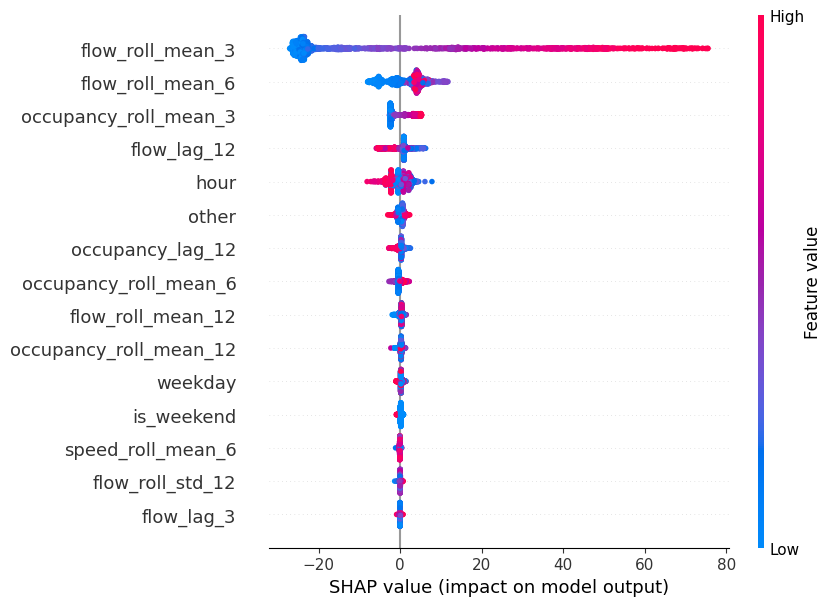

SHAP — mô hình sau GAN — Baseline_A | 6_XGBoost | best_ratio=0.0


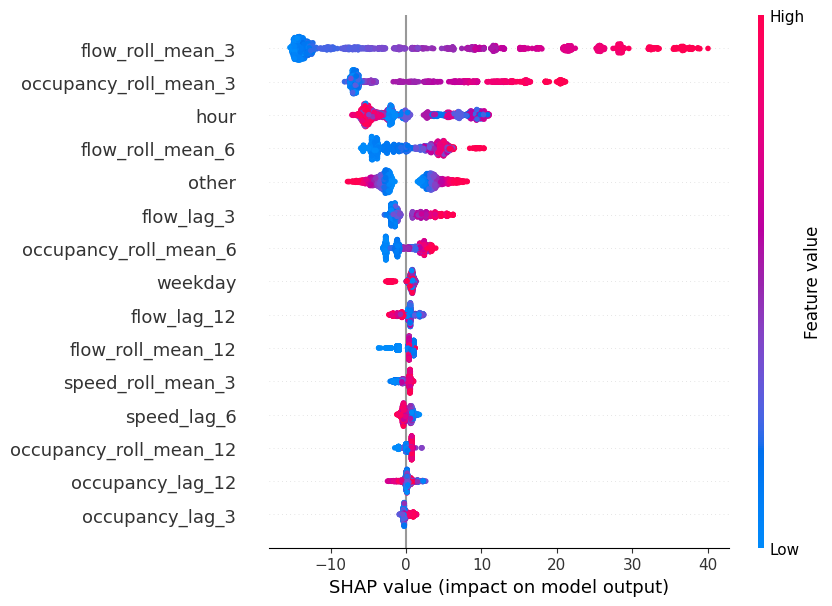

SHAP — mô hình sau GAN — Baseline_B | 5_RandomForest | best_ratio=0.0


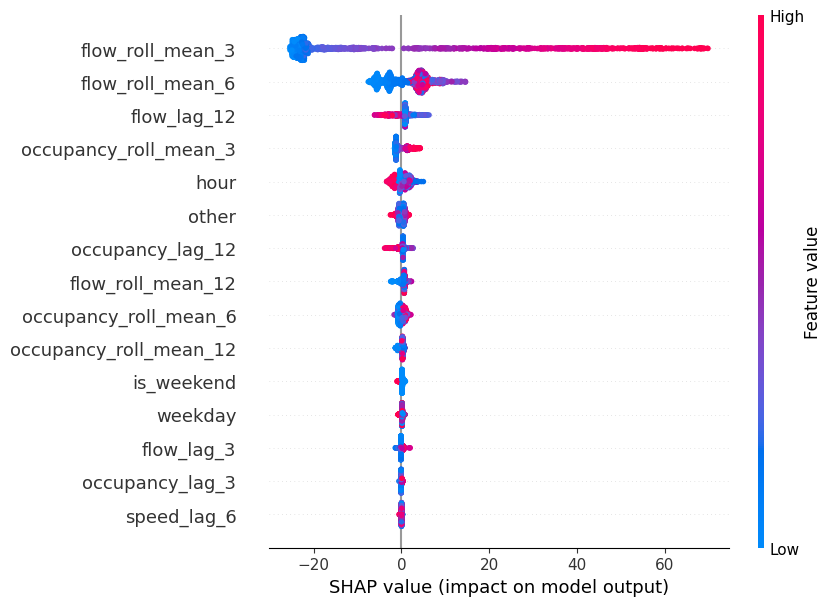

SHAP — mô hình sau GAN — Baseline_B | 6_XGBoost | best_ratio=0.0


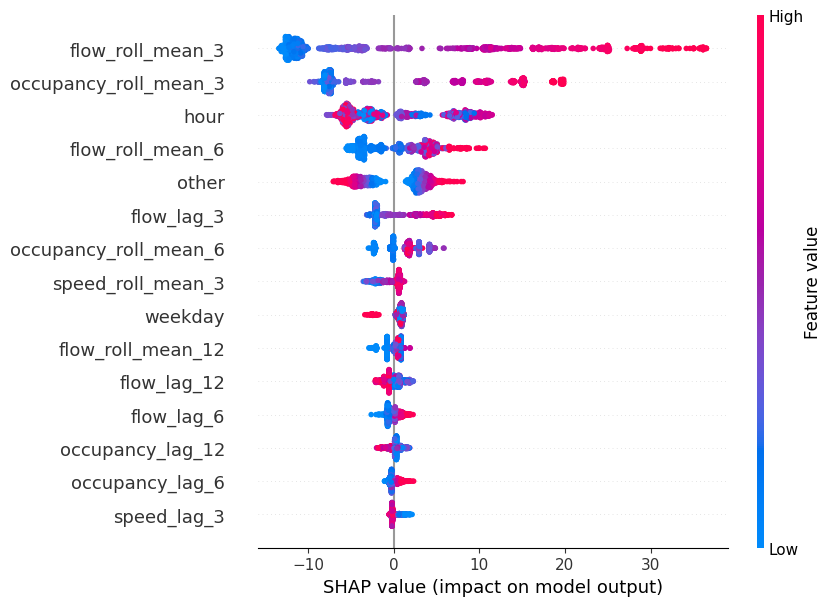

,stage,baseline,model,case,synthetic_ratio,feature,mean_abs_shap,is_other,rank
0,gan_best,Baseline_A,5_RandomForest,Baseline_A | 5_RandomForest,0.0,flow_roll_mean_3,26.932597,False,1
1,gan_best,Baseline_A,5_RandomForest,Baseline_A | 5_RandomForest,0.0,flow_roll_mean_6,4.041844,False,2
2,gan_best,Baseline_A,5_RandomForest,Baseline_A | 5_RandomForest,0.0,occupancy_roll_mean_3,2.627441,False,3
3,gan_best,Baseline_A,5_RandomForest,Baseline_A | 5_RandomForest,0.0,flow_lag_12,1.904509,False,4
4,gan_best,Baseline_A,5_RandomForest,Baseline_A | 5_RandomForest,0.0,hour,1.683387,False,5
5,gan_best,Baseline_A,5_RandomForest,Baseline_A | 5_RandomForest,0.0,other,0.690839,True,6
6,gan_best,Baseline_A,5_RandomForest,Baseline_A | 5_RandomForest,0.0,occupancy_lag_12,0.556951,False,7
7,gan_best,Baseline_A,5_RandomForest,Baseline_A | 5_RandomForest,0.0,occupancy_roll_mean_6,0.525231,False,8
8,gan_best,Baseline_A,5_RandomForest,Baseline_A | 5_RandomForest,0.0,flow_roll_mean_12,0.388810,False,9
9,gan_best,Baseline_A,5_RandomForest,Baseline_A | 5_RandomForest,0.0,occupancy_roll_mean_12,0.326960,False,10


,baseline,model,case,feature,optimized_rank,optimized_mean_abs_shap,gan_rank,gan_mean_abs_shap,synthetic_ratio,mean_abs_shap_delta
3,Baseline_A,5_RandomForest,Baseline_A | 5_RandomForest,flow_roll_mean_3,1.0,27.829809,1.0,26.932597,0.0,-0.897213
4,Baseline_A,5_RandomForest,Baseline_A | 5_RandomForest,flow_roll_mean_6,2.0,4.199434,2.0,4.041844,0.0,-0.157589
11,Baseline_A,5_RandomForest,Baseline_A | 5_RandomForest,occupancy_roll_mean_3,5.0,1.596044,3.0,2.627441,0.0,1.031397
0,Baseline_A,5_RandomForest,Baseline_A | 5_RandomForest,flow_lag_12,3.0,2.071449,4.0,1.904509,0.0,-0.166940
6,Baseline_A,5_RandomForest,Baseline_A | 5_RandomForest,hour,4.0,1.867680,5.0,1.683387,0.0,-0.184293
...,...,...,...,...,...,...,...,...,...,...
50,Baseline_B,6_XGBoost,Baseline_B | 6_XGBoost,flow_lag_6,13.0,0.439844,12.0,0.564422,0.0,0.124578
55,Baseline_B,6_XGBoost,Baseline_B | 6_XGBoost,occupancy_lag_12,14.0,0.338905,13.0,0.477852,0.0,0.138947
56,Baseline_B,6_XGBoost,Baseline_B | 6_XGBoost,occupancy_lag_6,12.0,0.501718,14.0,0.439806,0.0,-0.061912
61,Baseline_B,6_XGBoost,Baseline_B | 6_XGBoost,speed_lag_3,NaN,NaN,15.0,0.335862,0.0,NaN


In [48]:
gan_shap_results = {}
gan_shap_tables = []

for case in optimized_cases:
    baseline_name = case['baseline']
    model_name = case['model']
    case_name = case['case']
    params = optimized_params[baseline_name][model_name]
    real_test_df = gan_inputs[baseline_name]['test']
    aug_train_df = gan_best_train_frames[case_name]
    best_row = gan_best_rows[case_name]
    best_ratio = float(best_row['synthetic_ratio'])

    print(f'{"="*70}')
    print(f'SHAP — mô hình sau GAN — {case_name} | best_ratio={best_ratio}')
    print(f'{"="*70}')

    gan_model = stability.build_model(
        model_name=model_name,
        params=params,
        random_state=GAN_CONFIG['random_state'],
    )
    gan_model.fit(aug_train_df[FEATURE_COLS], aug_train_df[TARGET_COL].values)

    shap_result = explainability.compute_shap_values(
        model=gan_model,
        data_df=real_test_df,
        feature_cols=FEATURE_COLS,
        sample_size=XAI_CONFIG['shap_sample_size'],
        random_state=XAI_CONFIG['random_state'],
    )

    safe_ratio = str(best_ratio).replace('.', 'p')
    safe_prefix = f"{baseline_name}_{model_name}_gan_ratio_{safe_ratio}".replace('/', '_').replace(' ', '_')
    plot_result = explainability.plot_shap_summary(
        shap_result,
        save_dir=CONFIG['images_dir'],
        prefix=safe_prefix,
        max_display=XAI_CONFIG['top_features'] + 1,
        top_features=XAI_CONFIG['top_features'],
        other_label=XAI_CONFIG['other_label'],
    )

    shap_table = explainability.shap_top_other_table(
        shap_result,
        case=case_name,
        baseline=baseline_name,
        model=model_name,
        stage='gan_best',
        top_features=XAI_CONFIG['top_features'],
        other_label=XAI_CONFIG['other_label'],
    )
    shap_table.insert(4, 'synthetic_ratio', best_ratio)
    gan_shap_tables.append(shap_table)
    gan_shap_results[case_name] = {
        'model': gan_model,
        'best_ratio': best_ratio,
        'best_metrics': best_row,
        'shap_result': shap_result,
        'plot_result': plot_result,
        'table': shap_table,
    }

gan_shap_summary = pd.concat(gan_shap_tables, ignore_index=True)
gan_shap_summary.to_csv(
    f"{CONFIG['clean_dir']}/gan_shap_top14_other.csv",
    index=False,
)
display(gan_shap_summary)

original_cmp = optimized_shap_summary[
    ['baseline', 'model', 'case', 'feature', 'rank', 'mean_abs_shap']
].rename(columns={
    'rank': 'optimized_rank',
    'mean_abs_shap': 'optimized_mean_abs_shap',
})
gan_cmp = gan_shap_summary[
    ['baseline', 'model', 'case', 'feature', 'rank', 'mean_abs_shap', 'synthetic_ratio']
].rename(columns={
    'rank': 'gan_rank',
    'mean_abs_shap': 'gan_mean_abs_shap',
})

gan_xai_comparison = original_cmp.merge(
    gan_cmp,
    on=['baseline', 'model', 'case', 'feature'],
    how='outer',
)
gan_xai_comparison['mean_abs_shap_delta'] = (
    gan_xai_comparison['gan_mean_abs_shap']
    - gan_xai_comparison['optimized_mean_abs_shap']
)
gan_xai_comparison = gan_xai_comparison.sort_values(
    ['case', 'gan_mean_abs_shap', 'optimized_mean_abs_shap'],
    ascending=[True, False, False],
)
gan_xai_comparison.to_csv(
    f"{CONFIG['clean_dir']}/gan_xai_comparison.csv",
    index=False,
)
display(gan_xai_comparison)
